# Zomato Restaurant Data Analysis
### By - Pratyush Puri
### Linkedin - [www.linkedin.com/in/pratyushpuri](https://www.linkedin.com/in/pratyushpuri)


## Adding Dataset

In [72]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandas.plotting import parallel_coordinates
import matplotlib.patches as patches
import matplotlib.cm as cm
from math import pi

import warnings as w
w.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [34]:
df= pd.read_csv('/kaggle/input/zomato-restaurant-dataset/enhanced_zomato_dataset_clean.csv')
df.head()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,Votes,Prices,Average_Rating,Total_Votes,Price_per_Vote,Log_Price,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0,4.05,39,2.929412,5.521461,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0,4.05,39,2.804348,4.867534,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NONE,39,189.0,4.05,39,4.725000,5.247024,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0,4.05,39,4.295455,5.247024,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0,4.05,39,6.406250,5.327876,1,46,4.05,171.347826,3.81868,255.954894,3.939031,245.130482,1,0


## Data Exploration and Cleaning

In [35]:
df.shape

(123657, 26)

In [36]:
df.columns

Index(['Restaurant_Name', 'Dining_Rating', 'Delivery_Rating', 'Dining_Votes',
       'Delivery_Votes', 'Cuisine', 'Place_Name', 'City', 'Item_Name',
       'Best_Seller', 'Votes', 'Prices', 'Average_Rating', 'Total_Votes',
       'Price_per_Vote', 'Log_Price', 'Is_Bestseller', 'Restaurant_Popularity',
       'Avg_Rating_Restaurant', 'Avg_Price_Restaurant', 'Avg_Rating_Cuisine',
       'Avg_Price_Cuisine', 'Avg_Rating_City', 'Avg_Price_City',
       'Is_Highly_Rated', 'Is_Expensive'],
      dtype='object')

In [37]:
df.describe(include='all')

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Best_Seller,Votes,Prices,Average_Rating,Total_Votes,Price_per_Vote,Log_Price,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
count,123657,123657.000000,123657.000000,123657.000000,123657.000000,123657,123657,123657,123657,123657,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.0,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000,123657.000000
unique,826,NaN,NaN,NaN,NaN,48,324,17,55693,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,McDonald's,NaN,NaN,NaN,NaN,Beverages,C Scheme,Hyderabad,Veg Fried Rice,NONE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2059,NaN,NaN,NaN,NaN,39441,3775,15613,322,95715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3.822264,3.963184,152.729858,115.763725,NaN,NaN,NaN,NaN,NaN,24.666772,241.378399,3.892724,268.493583,154.707246,5.265611,1.0,304.008143,3.892724,241.378399,3.892724,241.378399,3.892724,241.378399,0.373970,0.243464
std,NaN,0.351407,0.244624,232.214061,243.970828,NaN,NaN,NaN,NaN,NaN,125.236009,192.830713,0.238449,292.811830,207.522162,0.699109,0.0,346.309371,0.229933,94.690020,0.074554,30.359509,0.025634,29.121965,0.483858,0.429174
min,NaN,2.500000,2.500000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.950000,3.000000,0.000000,0.006586,0.667829,1.0,4.000000,3.000000,35.833333,3.406122,61.428571,3.600000,194.591645,0.000000,0.000000
25%,NaN,3.700000,3.800000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,130.000000,3.750000,11.000000,11.000000,4.875197,1.0,125.000000,3.750000,178.460526,3.873352,212.572315,3.880503,223.676576,0.000000,0.000000
50%,NaN,3.822264,4.000000,30.000000,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,208.570000,3.911132,158.000000,95.000000,5.345058,1.0,195.000000,3.911132,230.959514,3.913401,254.565364,3.889413,235.550603,0.000000,0.000000
75%,NaN,4.000000,4.100000,217.000000,23.000000,NaN,NaN,NaN,NaN,NaN,15.000000,299.000000,4.050000,447.000000,245.000000,5.703782,1.0,318.000000,4.050000,285.146825,3.928624,255.954894,3.907014,245.130482,1.000000,0.000000


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Restaurant_Name        123657 non-null  object 
 1   Dining_Rating          123657 non-null  float64
 2   Delivery_Rating        123657 non-null  float64
 3   Dining_Votes           123657 non-null  int64  
 4   Delivery_Votes         123657 non-null  int64  
 5   Cuisine                123657 non-null  object 
 6   Place_Name             123657 non-null  object 
 7   City                   123657 non-null  object 
 8   Item_Name              123657 non-null  object 
 9   Best_Seller            123657 non-null  object 
 10  Votes                  123657 non-null  int64  
 11  Prices                 123657 non-null  float64
 12  Average_Rating         123657 non-null  float64
 13  Total_Votes            123657 non-null  int64  
 14  Price_per_Vote         123657 non-nu

In [39]:
df.isnull().any()

Restaurant_Name          False
Dining_Rating            False
Delivery_Rating          False
Dining_Votes             False
Delivery_Votes           False
Cuisine                  False
Place_Name               False
City                     False
Item_Name                False
Best_Seller              False
Votes                    False
Prices                   False
Average_Rating           False
Total_Votes              False
Price_per_Vote           False
Log_Price                False
Is_Bestseller            False
Restaurant_Popularity    False
Avg_Rating_Restaurant    False
Avg_Price_Restaurant     False
Avg_Rating_Cuisine       False
Avg_Price_Cuisine        False
Avg_Rating_City          False
Avg_Price_City           False
Is_Highly_Rated          False
Is_Expensive             False
dtype: bool

In [40]:
df.duplicated().sum()

22127

In [41]:
df = df.drop_duplicates()

In [42]:
print("Number of duplicates : ",df.duplicated().sum())
print("Shape of Dataset : ",df.shape)

Number of duplicates :  0
Shape of Dataset :  (101530, 26)


In [43]:
df.rename(columns={'Best_Seller': 'Item_Rating'}, inplace=True)
df.sample()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Item_Rating,Votes,Prices,Average_Rating,Total_Votes,Price_per_Vote,Log_Price,Is_Bestseller,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
45170,Third Wave Coffee,4.0,4.3,36,664,Pizza,Karve Nagar,Pune,Chocolate Croissant,MUST TRY,23,227.62,4.15,700,9.484167,5.432061,1,144,4.15,265.429375,3.885698,208.939511,3.882244,242.170568,1,0


In [44]:
df.nunique()

Restaurant_Name            826
Dining_Rating               25
Delivery_Rating             19
Dining_Votes               294
Delivery_Votes             263
Cuisine                     48
Place_Name                 324
City                        17
Item_Name                55693
Item_Rating                 14
Votes                      760
Prices                    2710
Average_Rating              52
Total_Votes                450
Price_per_Vote           13496
Log_Price                 2710
Is_Bestseller                1
Restaurant_Popularity      308
Avg_Rating_Restaurant      119
Avg_Price_Restaurant       824
Avg_Rating_Cuisine          46
Avg_Price_Cuisine           48
Avg_Rating_City             17
Avg_Price_City              17
Is_Highly_Rated              2
Is_Expensive                 2
dtype: int64

We can see here that column ***Is_Bestseller*** is always providing same result as it has only 1 unique values so we are going to drop such columns which is unnecessary

In [45]:
df = df.drop(columns=['Is_Bestseller'])
df.sample()

,Restaurant_Name,Dining_Rating,Delivery_Rating,Dining_Votes,Delivery_Votes,Cuisine,Place_Name,City,Item_Name,Item_Rating,Votes,Prices,Average_Rating,Total_Votes,Price_per_Vote,Log_Price,Restaurant_Popularity,Avg_Rating_Restaurant,Avg_Price_Restaurant,Avg_Rating_Cuisine,Avg_Price_Cuisine,Avg_Rating_City,Avg_Price_City,Is_Highly_Rated,Is_Expensive
19952,Mainland China,3.822264,4.1,0,643,Sichuan,Lower Parel,Mumbai,Seafood Coriander Soup,NONE,0,365.0,3.961132,643,365.0,5.902633,164,3.961132,550.213659,3.862784,254.494549,3.886635,304.402778,0,1


## Outlier Detection and Handling
### Outlier Analysis

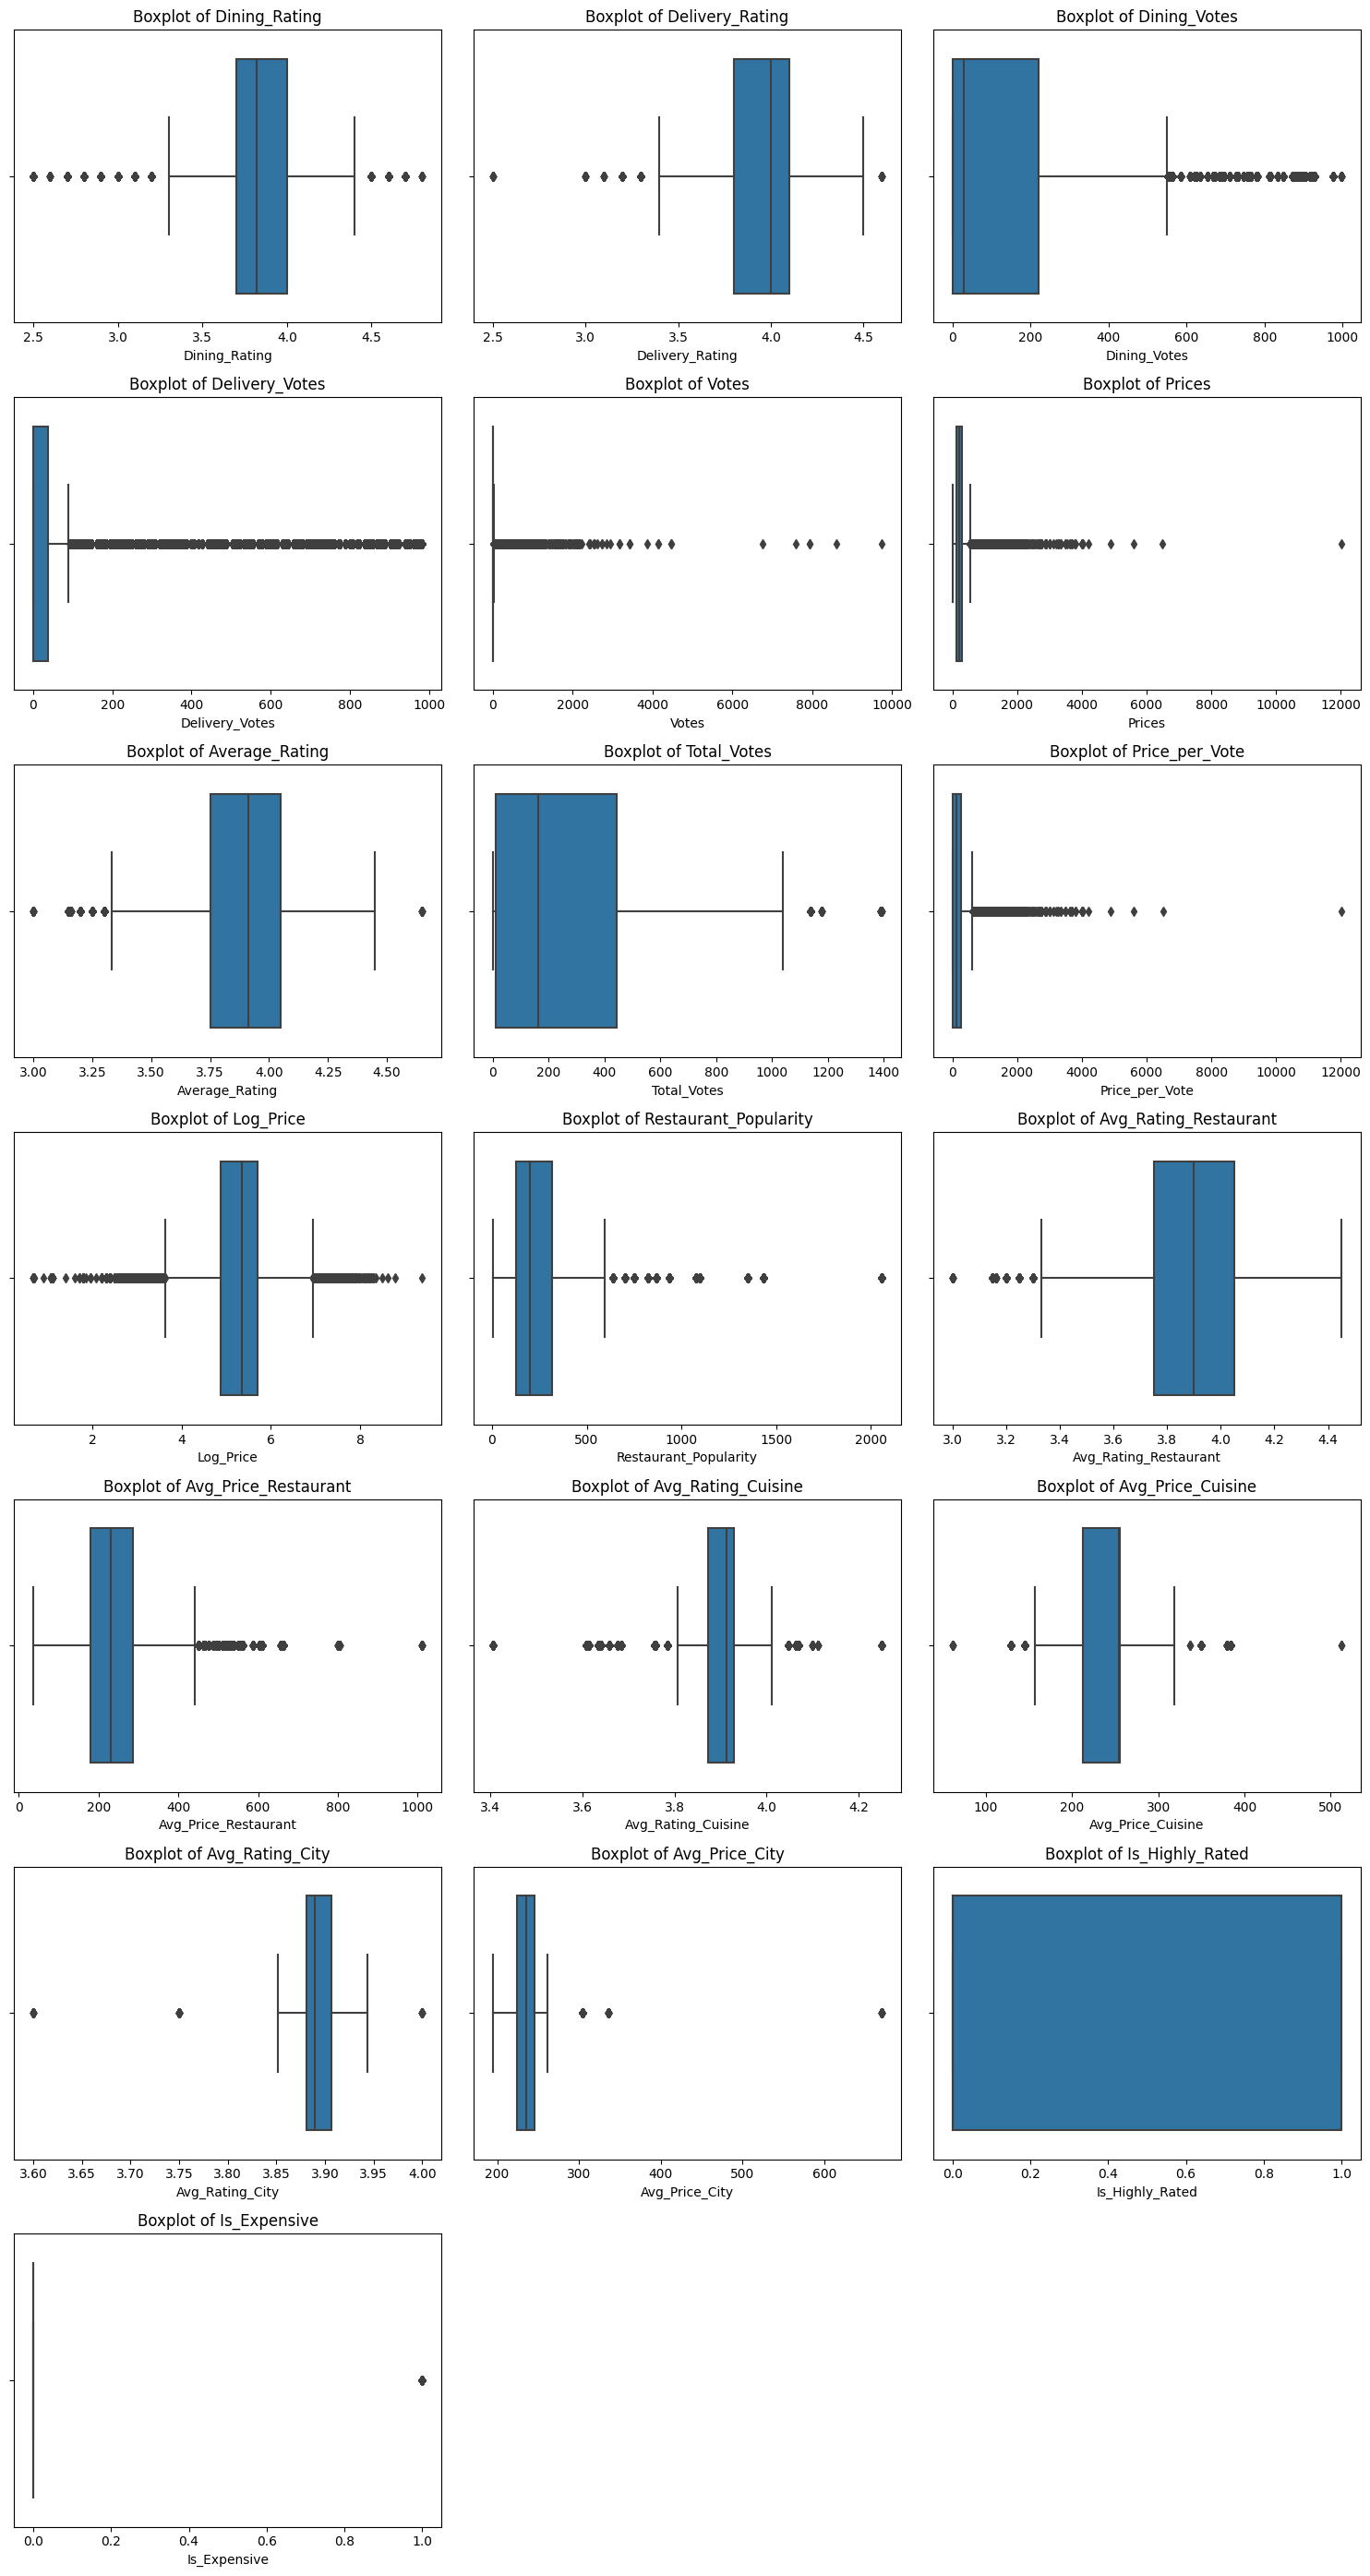

In [46]:
# all numerical columns
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
cols_per_row = 3
rows_needed = (len(numerical_cols) + cols_per_row - 1) // cols_per_row

# Subplot 
fig, axes = plt.subplots(nrows=rows_needed, ncols=cols_per_row, figsize=(15, rows_needed * 4))
axes = axes.flatten()

# boxplot for each column
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].grid(False) 

# hiding extra axes if less charts present
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Outlier Handling

In [47]:
# only numerical data
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]

# capping of each column
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    # Winsorization: clip values to lower/upper limit
    df[col] = np.where(df[col] < lower_limit, lower_limit, df[col])
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])

print("Outliers handled with Winsorization using IQR:")
print(df.head())  

Outliers handled with Winsorization using IQR:
  Restaurant_Name  Dining_Rating  Delivery_Rating  Dining_Votes  \
0      Doner King            3.9              4.2          39.0   
1      Doner King            3.9              4.2          39.0   
2      Doner King            3.9              4.2          39.0   
3      Doner King            3.9              4.2          39.0   
4      Doner King            3.9              4.2          39.0   

   Delivery_Votes    Cuisine Place_Name        City                 Item_Name  \
0             0.0  Fast Food   Malakpet   Hyderabad       Platter Kebab Combo   
1             0.0  Fast Food   Malakpet   Hyderabad   Chicken Rumali Shawarma   
2             0.0  Fast Food   Malakpet   Hyderabad    Chicken Tandoori Salad   
3             0.0  Fast Food   Malakpet   Hyderabad         Chicken BBQ Salad   
4             0.0  Fast Food   Malakpet   Hyderabad  Special Doner Wrap Combo   

  Item_Rating  Votes  Prices  Average_Rating  Total_Votes  Pric

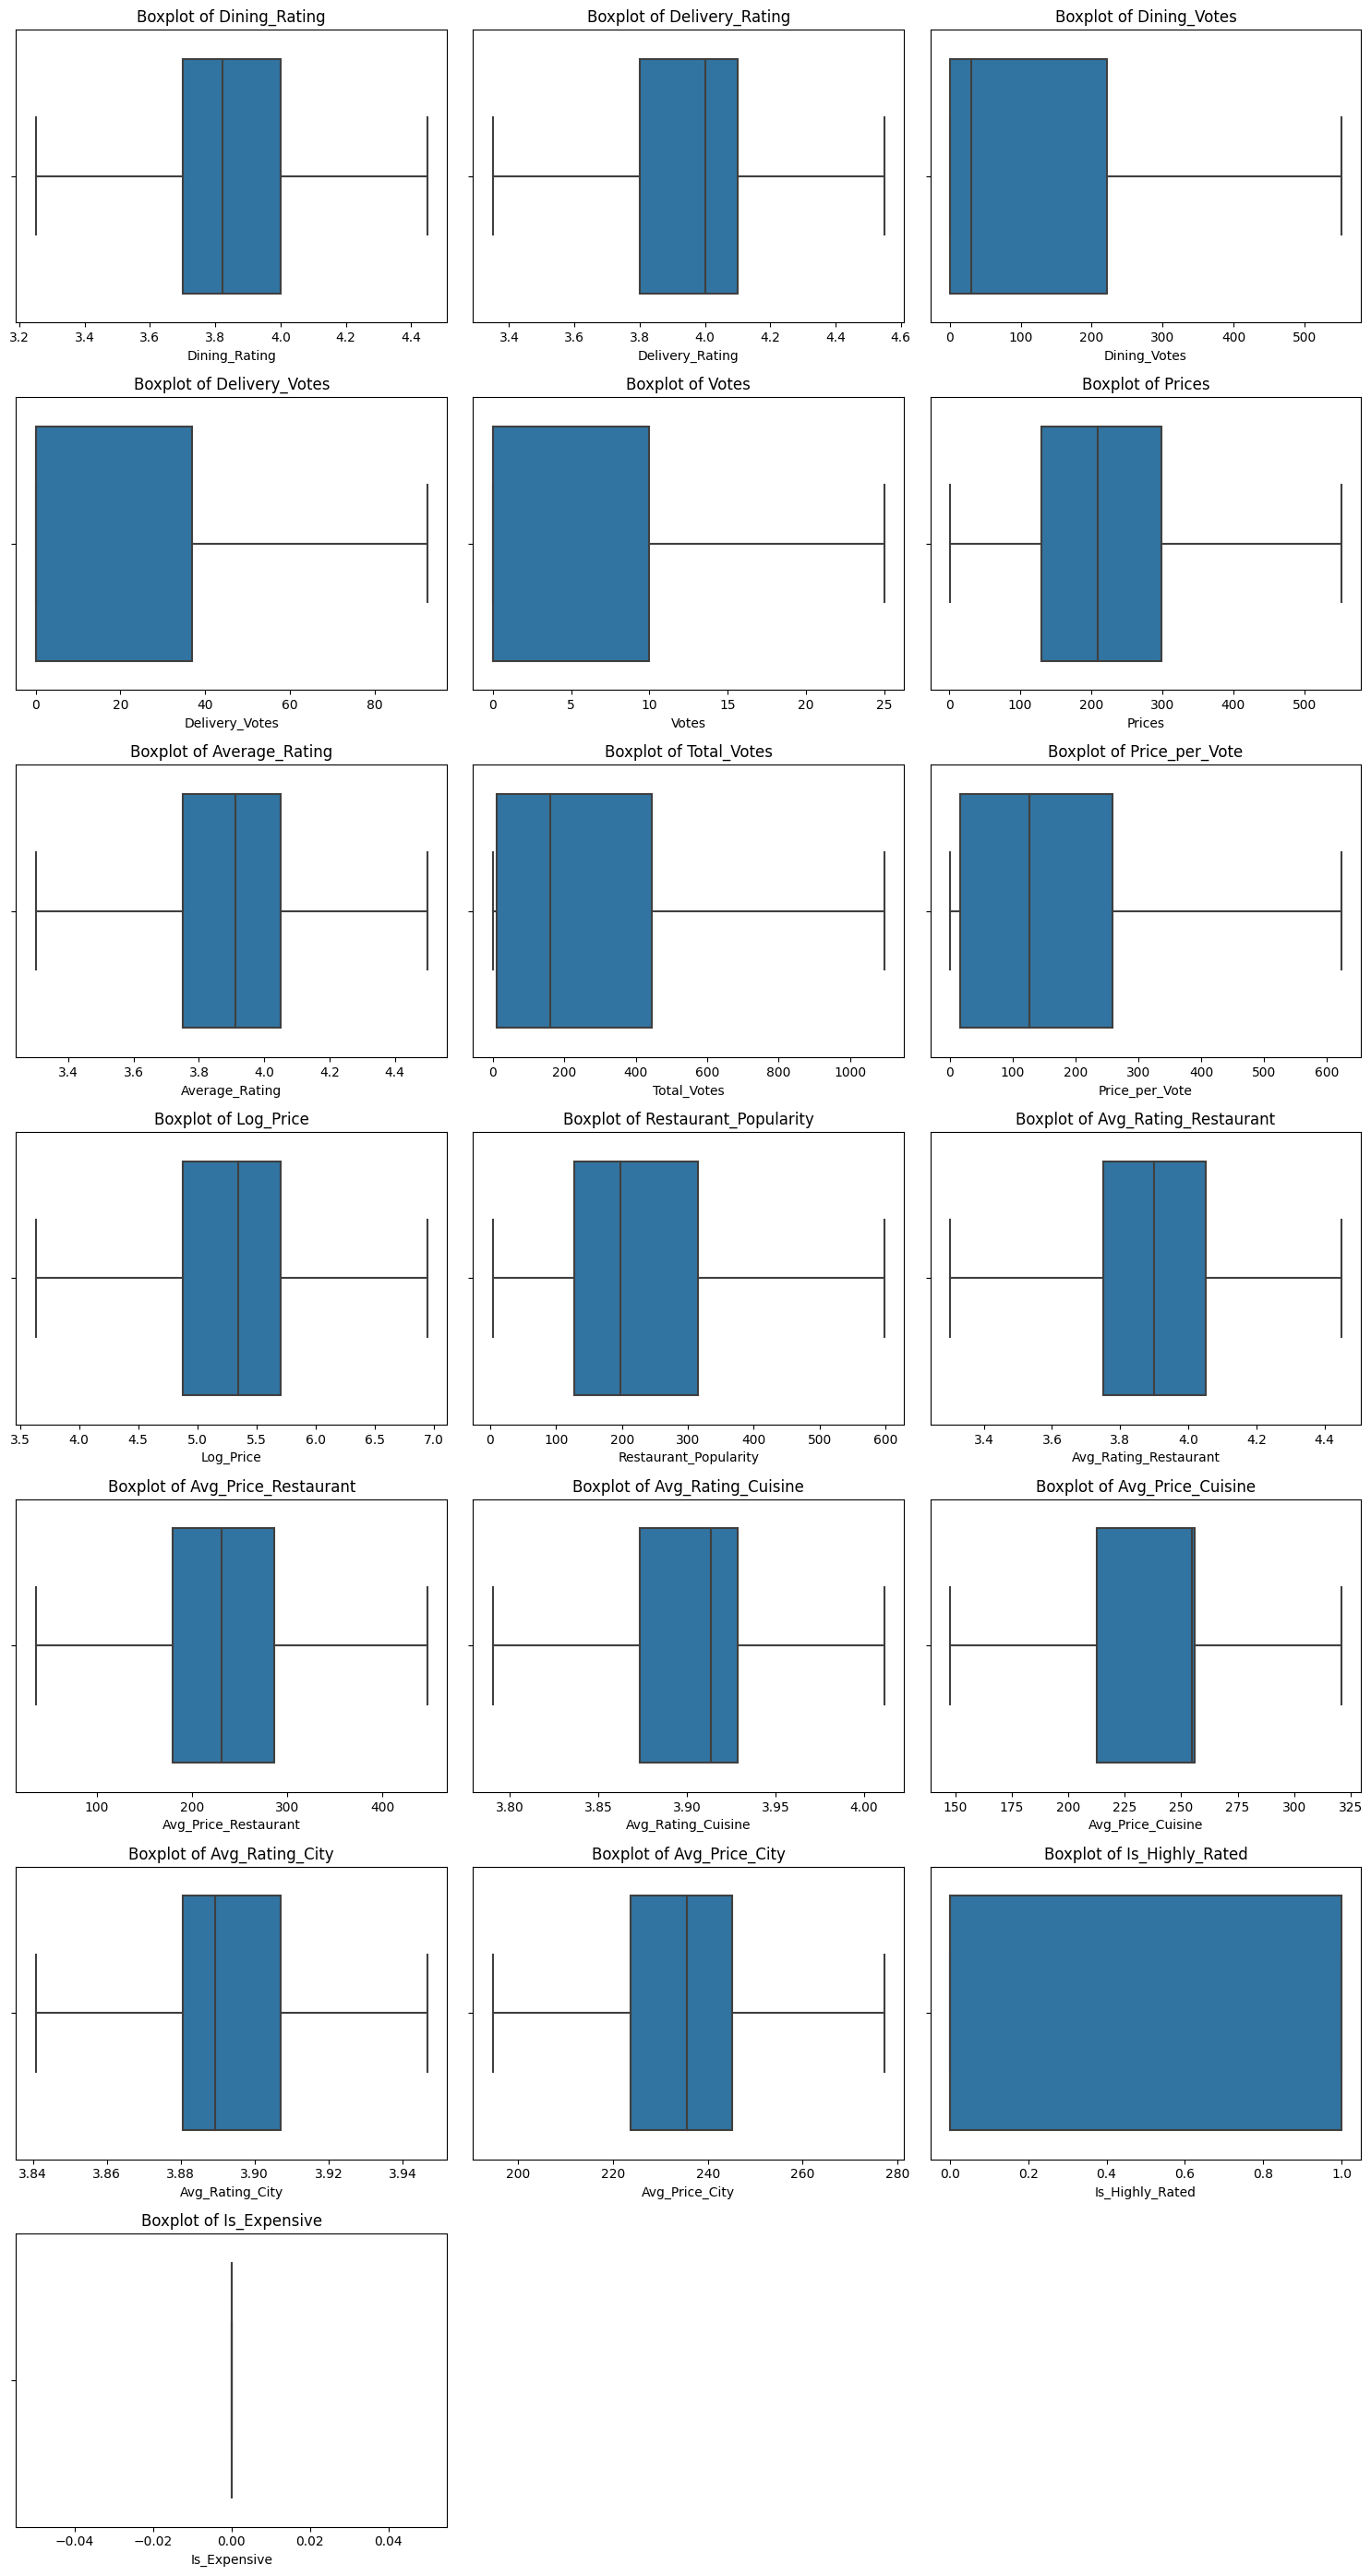

In [48]:
# all numerical columns
numerical_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
cols_per_row = 3
rows_needed = (len(numerical_cols) + cols_per_row - 1) // cols_per_row

# Subplot 
fig, axes = plt.subplots(nrows=rows_needed, ncols=cols_per_row, figsize=(15, rows_needed * 4))
axes = axes.flatten()

# boxplot for each column
for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].grid(False) 

# hiding extra axes if less charts present
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Exploratory Data Analysis

### What is the distribution of restaurant ratings across different cities?

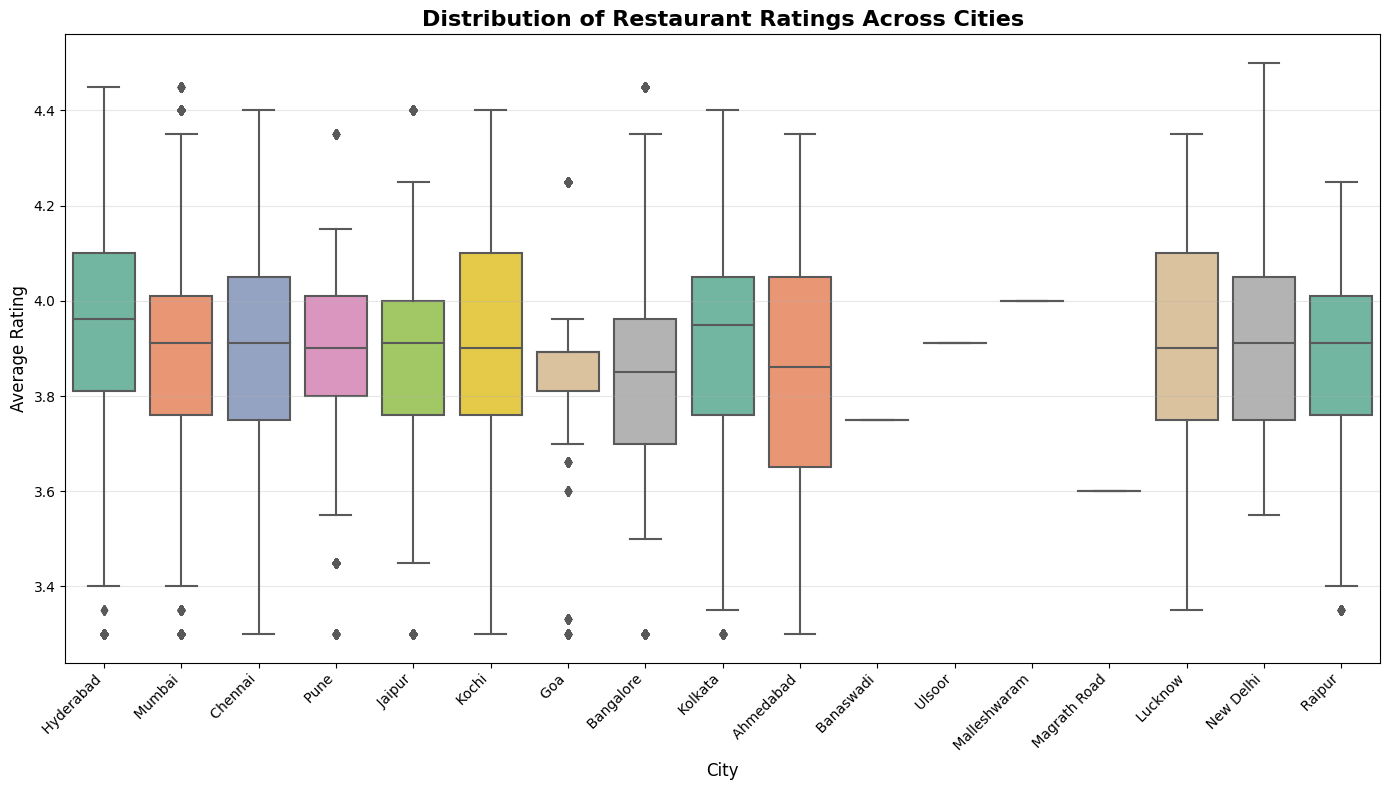

In [49]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='City', y='Average_Rating', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Restaurant Ratings Across Cities', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Hyderabad shows the most consistent rating distribution around 3.9, while smaller cities display more variation in restaurant quality ratings.

### How do prices vary across different cuisine types?

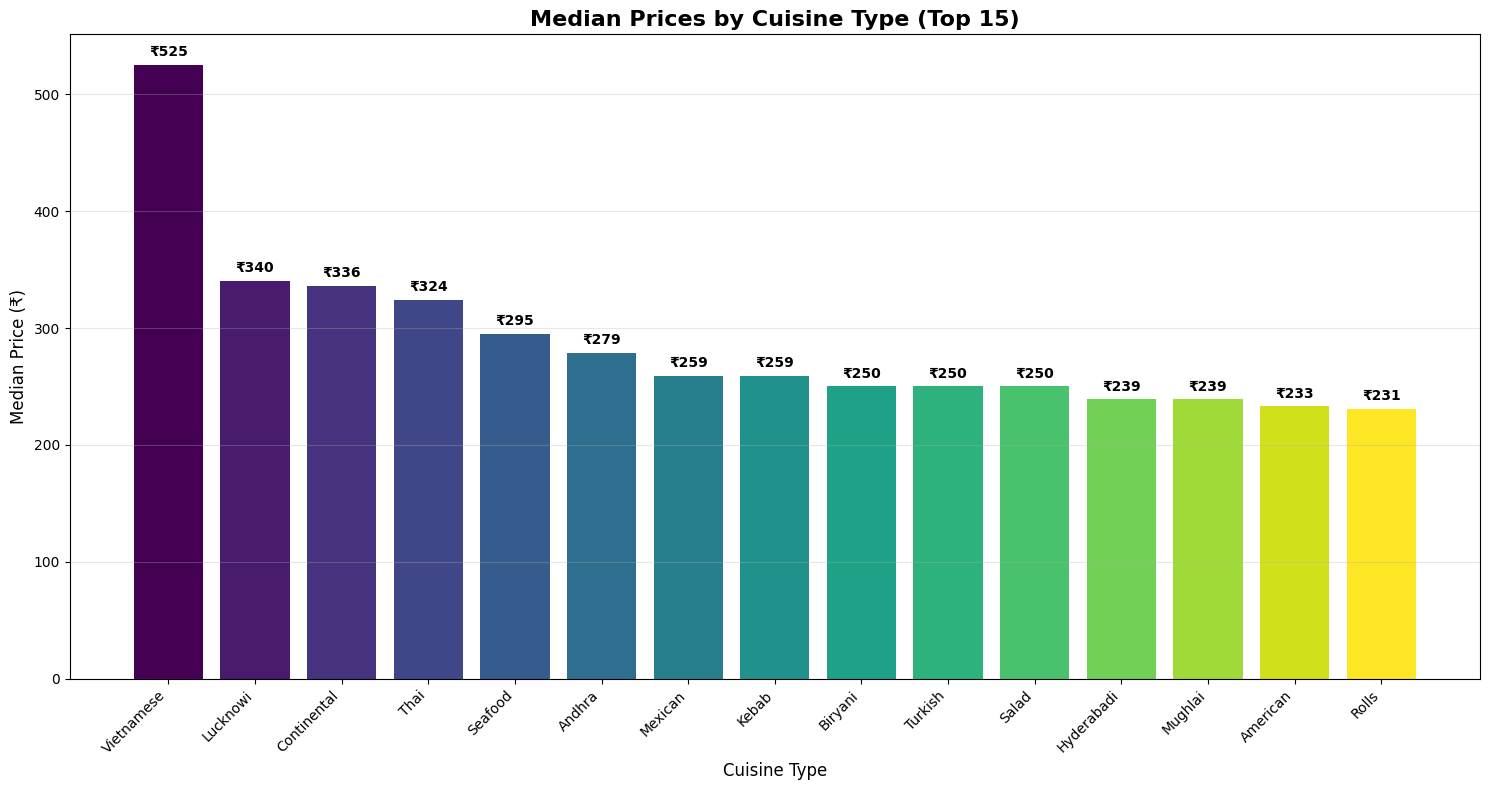

In [50]:
plt.figure(figsize=(15, 8))
cuisine_price = df.groupby('Cuisine')['Prices'].median().sort_values(ascending=False).head(15)
bars = plt.bar(range(len(cuisine_price)), cuisine_price.values, 
               color=plt.cm.viridis(np.linspace(0, 1, len(cuisine_price))))
plt.xticks(range(len(cuisine_price)), cuisine_price.index, rotation=45, ha='right')
plt.title('Median Prices by Cuisine Type (Top 15)', fontsize=16, fontweight='bold')
plt.xlabel('Cuisine Type', fontsize=12)
plt.ylabel('Median Price (₹)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(cuisine_price.values):
    plt.text(i, v + 5, f'₹{v:.0f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Continental and North Indian cuisines command premium pricing, while Beverages and Fast Food categories maintain more affordable price points.

### What is the relationship between restaurant popularity and average rating?

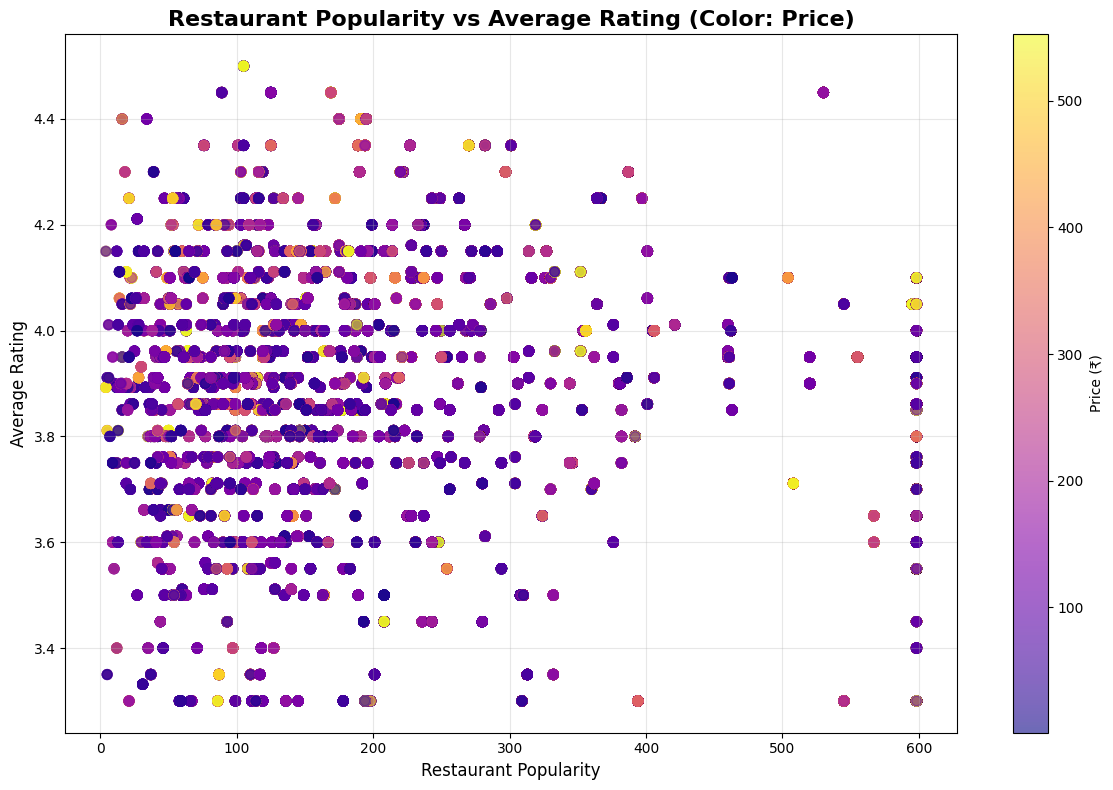

In [51]:
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Restaurant_Popularity'], df['Average_Rating'], 
                     c=df['Prices'], cmap='plasma', alpha=0.6, s=50)
plt.colorbar(scatter, label='Price (₹)')
plt.xlabel('Restaurant Popularity', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.title('Restaurant Popularity vs Average Rating (Color: Price)', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Higher popularity correlates with better ratings, while expensive items cluster in high-rated, popular restaurants, indicating premium positioning strategies.

### What is the price distribution pattern across the dataset?

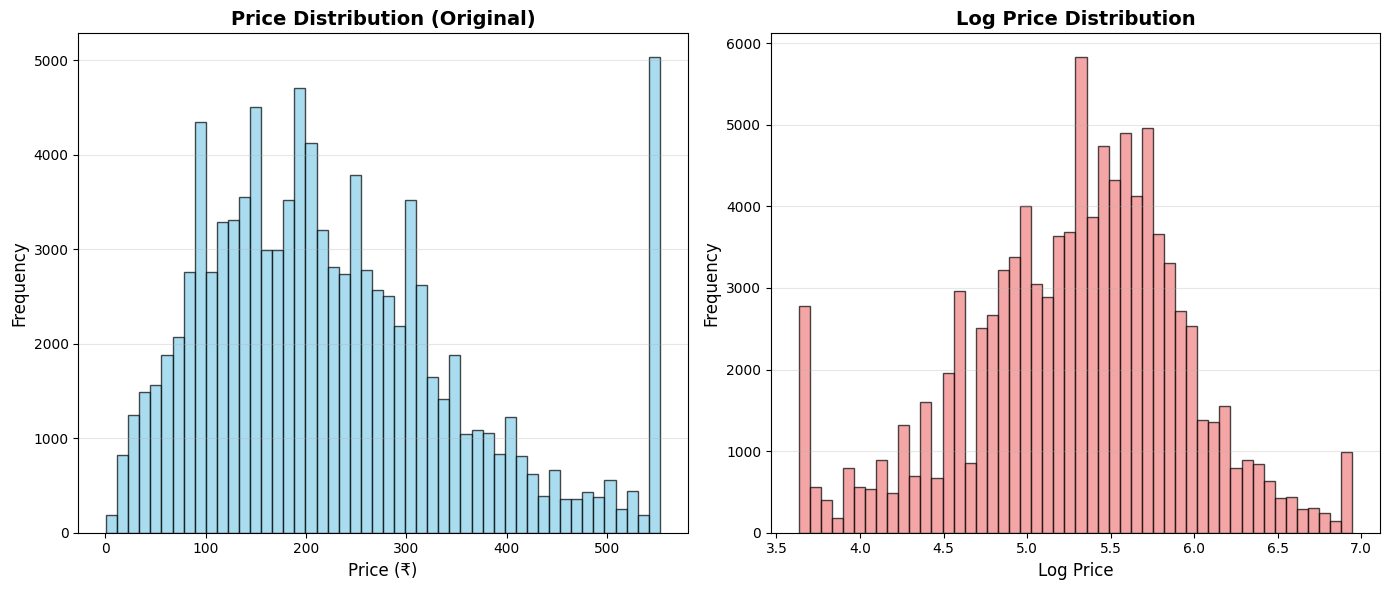

In [52]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.hist(df['Prices'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
plt.title('Price Distribution (Original)', fontsize=14, fontweight='bold')
plt.xlabel('Price (₹)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(df['Log_Price'], bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
plt.title('Log Price Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Log Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Price distribution is heavily right-skewed with most items under ₹300, while log transformation reveals more normal distribution patterns.

### How do dining and delivery ratings compare across restaurants?

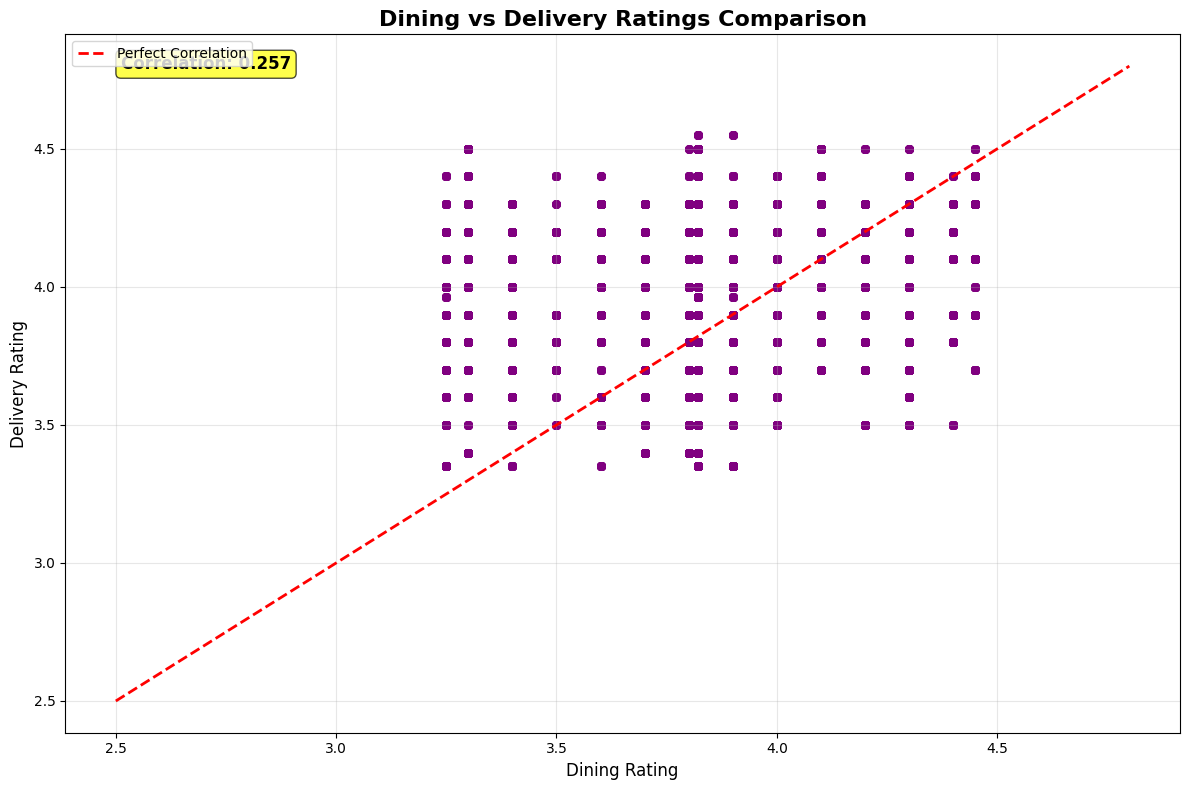

In [53]:
plt.figure(figsize=(12, 8))
plt.scatter(df['Dining_Rating'], df['Delivery_Rating'], alpha=0.5, s=30, color='purple')
plt.plot([2.5, 4.8], [2.5, 4.8], 'r--', linewidth=2, label='Perfect Correlation')
plt.xlabel('Dining Rating', fontsize=12)
plt.ylabel('Delivery Rating', fontsize=12)
plt.title('Dining vs Delivery Ratings Comparison', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
correlation = df['Dining_Rating'].corr(df['Delivery_Rating'])
plt.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=plt.gca().transAxes, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
         fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Strong positive correlation between dining and delivery ratings suggests consistent service quality across different restaurant operational channels.

### How do dining and delivery ratings compare across restaurants?

<Figure size 1500x1000 with 0 Axes>

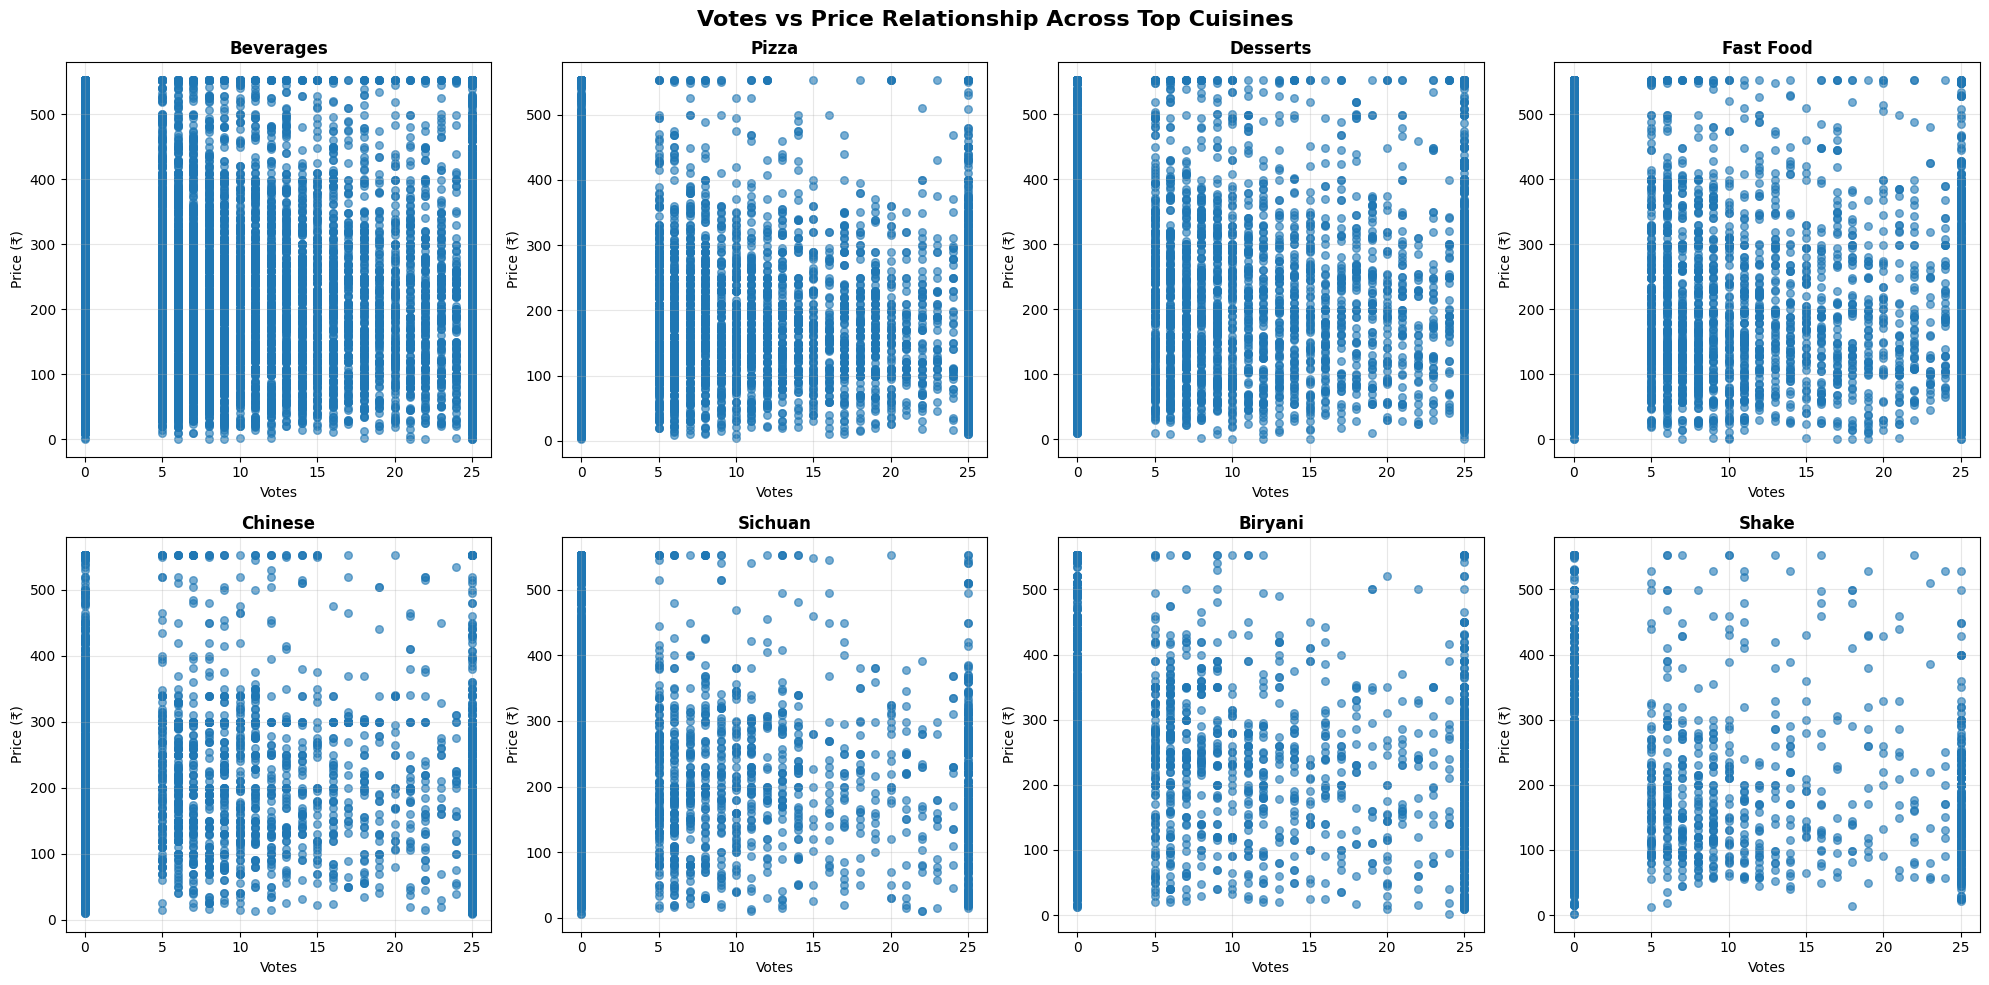

In [54]:
plt.figure(figsize=(15, 10))
top_cuisines = df['Cuisine'].value_counts().head(8).index
cuisine_data = df[df['Cuisine'].isin(top_cuisines)]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, cuisine in enumerate(top_cuisines):
    data = cuisine_data[cuisine_data['Cuisine'] == cuisine]
    axes[i].scatter(data['Votes'], data['Prices'], alpha=0.6, s=30)
    axes[i].set_title(f'{cuisine}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Votes', fontsize=10)
    axes[i].set_ylabel('Price (₹)', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Votes vs Price Relationship Across Top Cuisines', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Strong positive correlation between dining and delivery ratings suggests consistent service quality across different restaurant operational channels.

### What is the rating performance comparison between highly rated and regular restaurants?

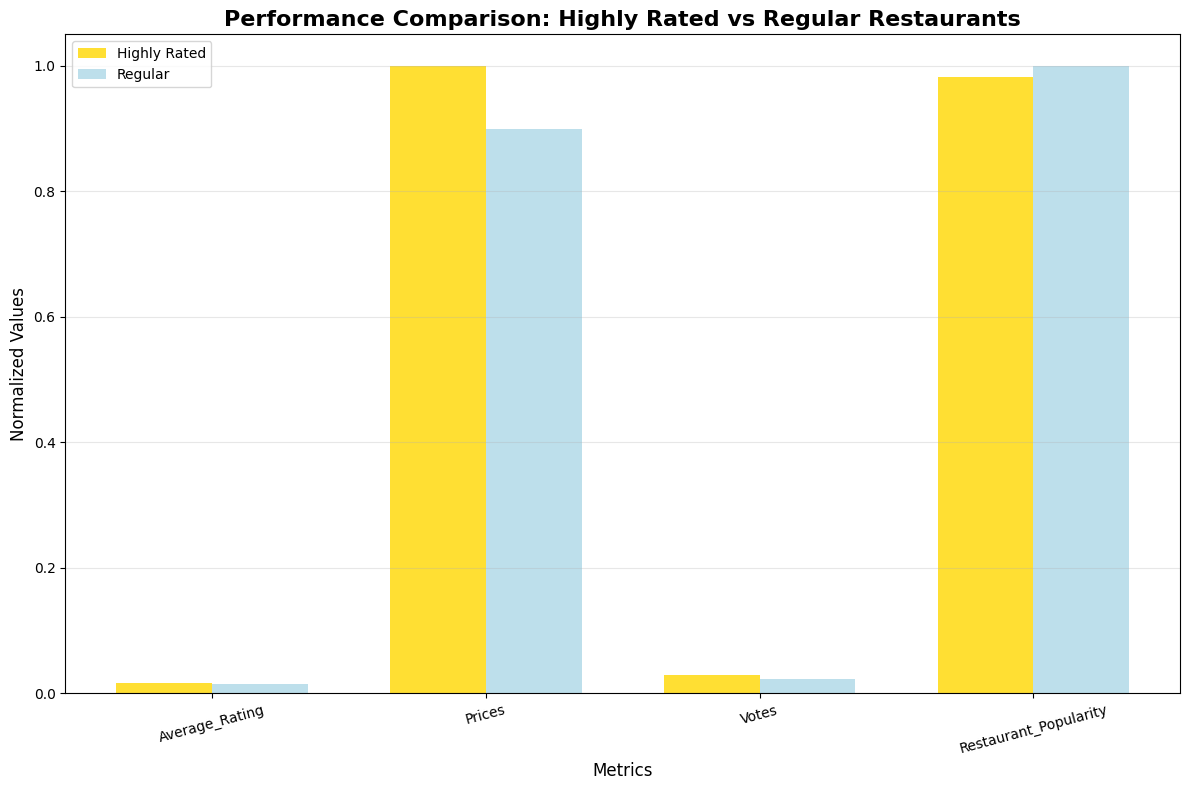

In [55]:
plt.figure(figsize=(12, 8))
rating_comparison = df.groupby('Is_Highly_Rated').agg({
    'Average_Rating': 'mean',
    'Prices': 'mean',
    'Votes': 'mean',
    'Restaurant_Popularity': 'mean'
}).round(2)

x = np.arange(len(rating_comparison.columns))
width = 0.35

highly_rated = rating_comparison.loc[1].values
regular = rating_comparison.loc[0].values

# Normalize values for better comparison
highly_rated_norm = highly_rated / highly_rated.max()
regular_norm = regular / regular.max()

bars1 = plt.bar(x - width/2, highly_rated_norm, width, label='Highly Rated', color='gold', alpha=0.8)
bars2 = plt.bar(x + width/2, regular_norm, width, label='Regular', color='lightblue', alpha=0.8)

plt.xlabel('Metrics', fontsize=12)
plt.ylabel('Normalized Values', fontsize=12)
plt.title('Performance Comparison: Highly Rated vs Regular Restaurants', fontsize=16, fontweight='bold')
plt.xticks(x, rating_comparison.columns, rotation=15)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Highly rated restaurants excel across all metrics with superior ratings, higher prices, more votes, and greater popularity.

### How does the price-per-vote ratio vary across different restaurant popularity levels?

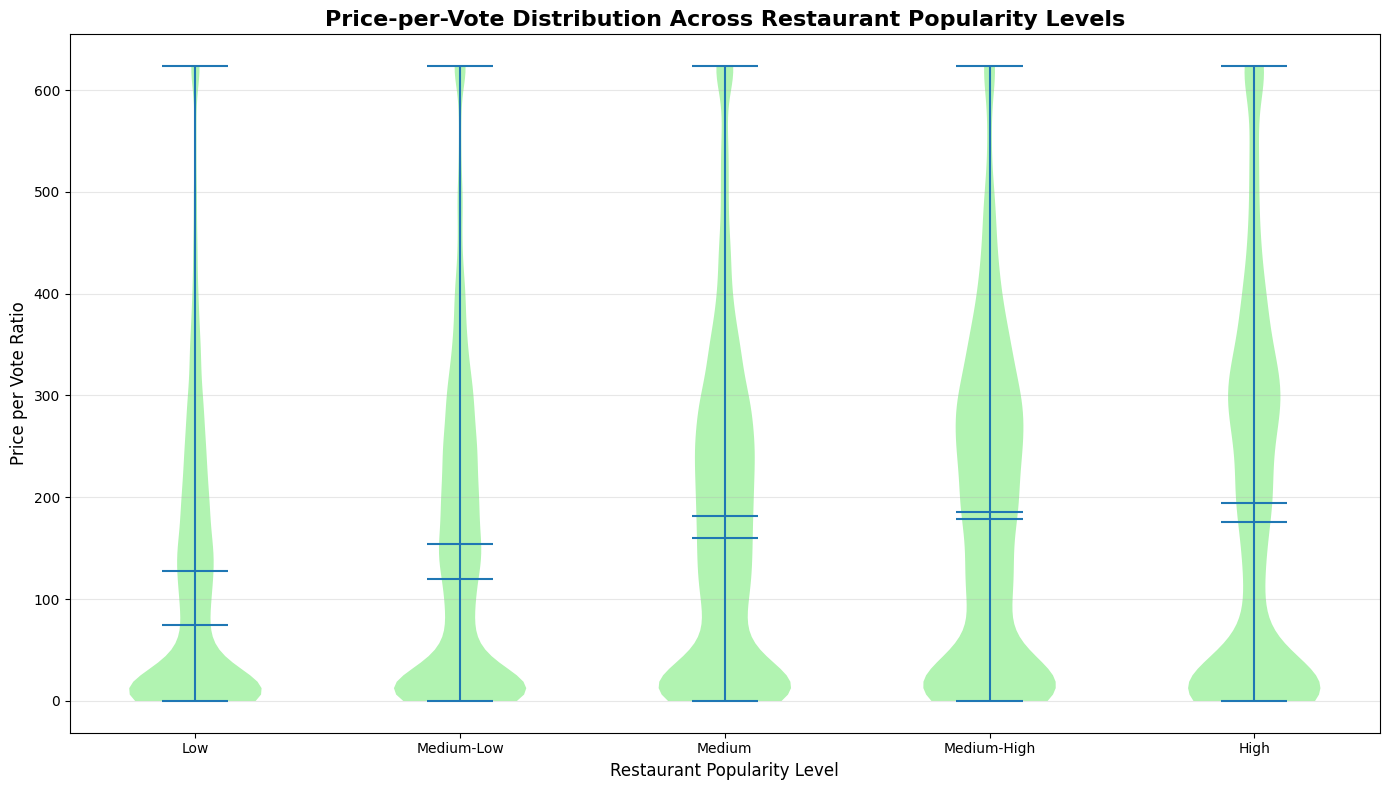

In [56]:
plt.figure(figsize=(14, 8))
df['Popularity_Bins'] = pd.cut(df['Restaurant_Popularity'], bins=5, labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])
violin_data = [df[df['Popularity_Bins'] == cat]['Price_per_Vote'].dropna() for cat in df['Popularity_Bins'].cat.categories]

parts = plt.violinplot(violin_data, positions=range(1, 6), showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightgreen')
    pc.set_alpha(0.7)

plt.xticks(range(1, 6), ['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])
plt.xlabel('Restaurant Popularity Level', fontsize=12)
plt.ylabel('Price per Vote Ratio', fontsize=12)
plt.title('Price-per-Vote Distribution Across Restaurant Popularity Levels', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Higher popularity restaurants demonstrate better price-per-vote efficiency, indicating optimal pricing strategies that balance customer satisfaction with revenue generation.

### How are bestseller items distributed across different categories?

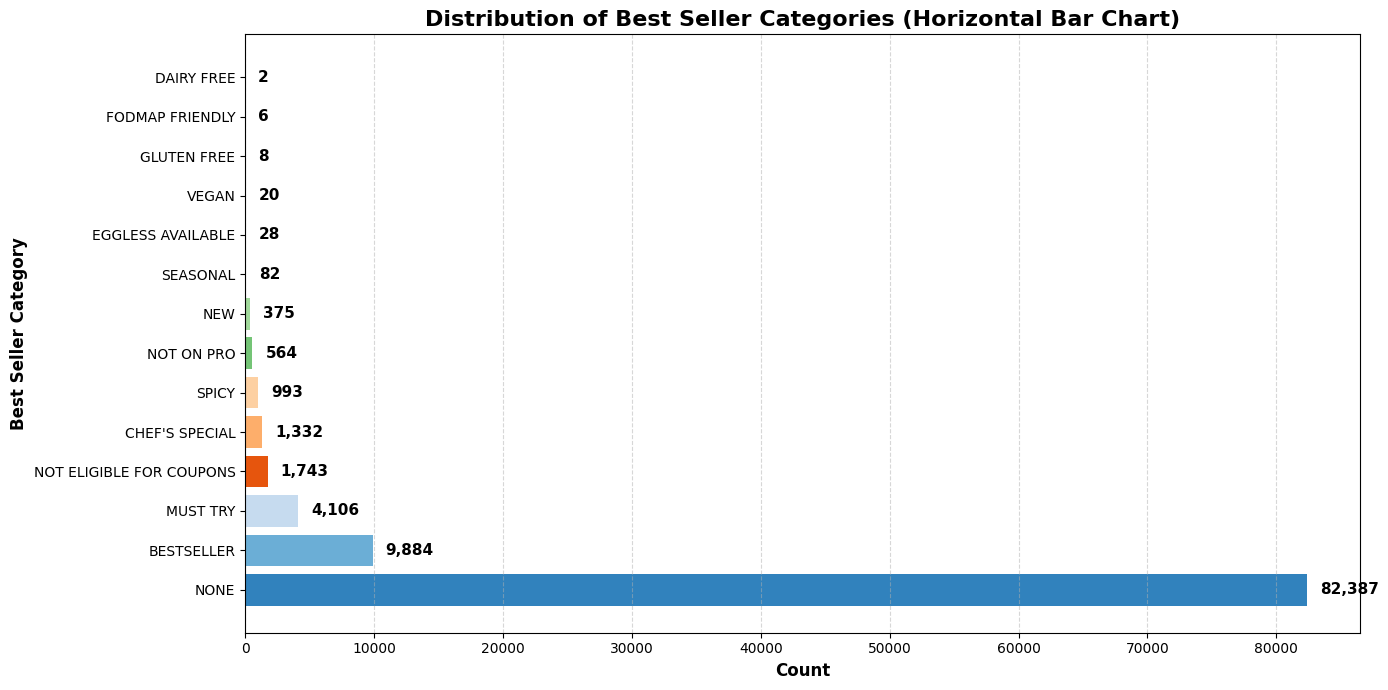

In [57]:
plt.figure(figsize=(14, 7))
bestseller_counts = df['Item_Rating'].value_counts()
colors = plt.cm.tab20c(np.linspace(0, 1, len(bestseller_counts)))

bars = plt.barh(bestseller_counts.index, bestseller_counts.values, color=colors)

plt.xlabel('Count', fontsize=12, fontweight='bold')
plt.ylabel('Best Seller Category', fontsize=12, fontweight='bold')
plt.title('Distribution of Best Seller Categories (Horizontal Bar Chart)', fontsize=16, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add count labels on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1000, bar.get_y() + bar.get_height() / 2, 
             f'{width:,}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

**Insight**: Majority items lack bestseller designation, suggesting untapped potential for menu optimization and strategic item promotion across restaurant portfolios.

### Some More Visualizations
#### Correlation Heatmap of Numerical Variables

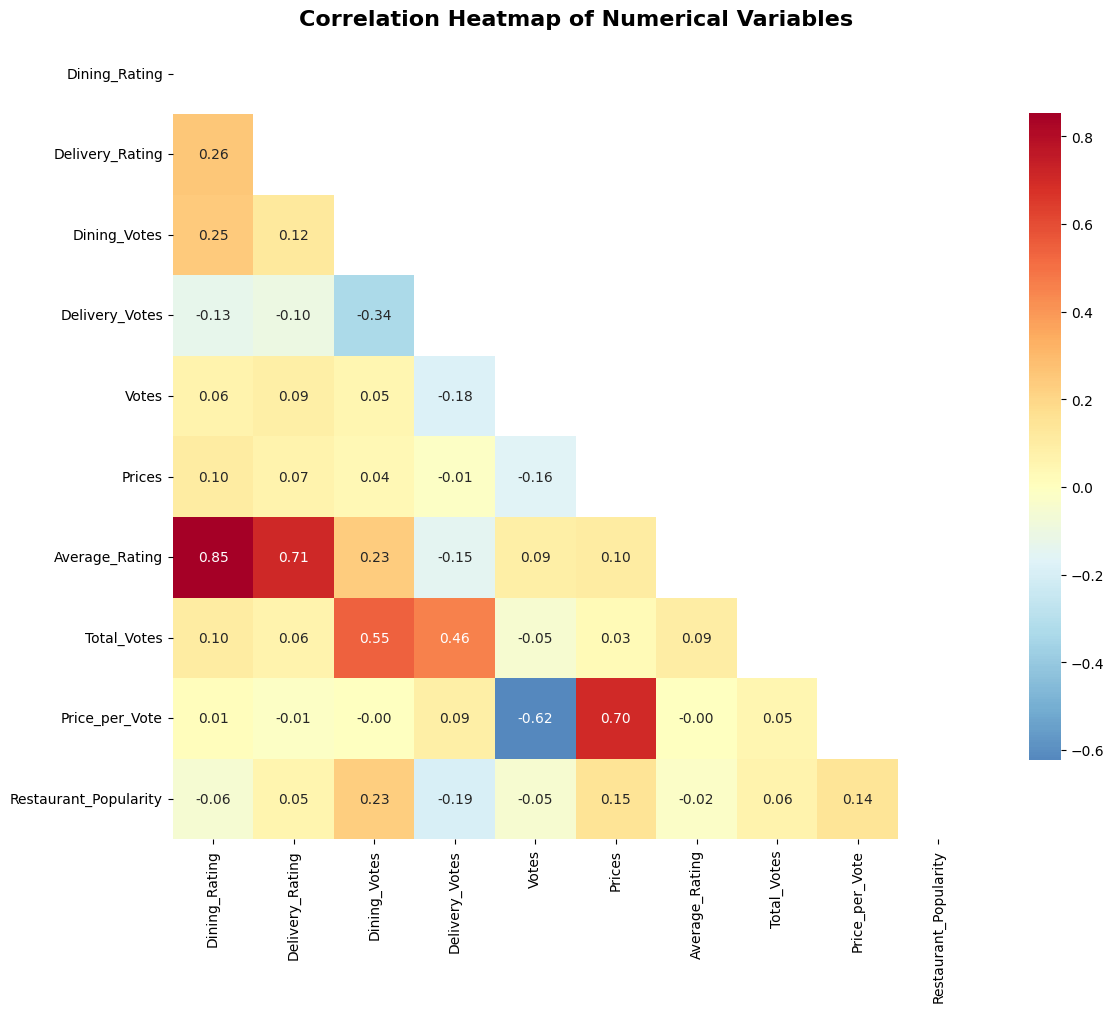

In [58]:
plt.figure(figsize=(12, 10))
numeric_cols = ['Dining_Rating', 'Delivery_Rating', 'Dining_Votes', 'Delivery_Votes', 
                'Votes', 'Prices', 'Average_Rating', 'Total_Votes', 'Price_per_Vote', 
                'Restaurant_Popularity']
correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Strong positive correlations exist between dining/delivery ratings and average ratings, while price-per-vote shows negative correlation with votes.

#### Cuisine Distribution Across Cities

<Figure size 1600x800 with 0 Axes>

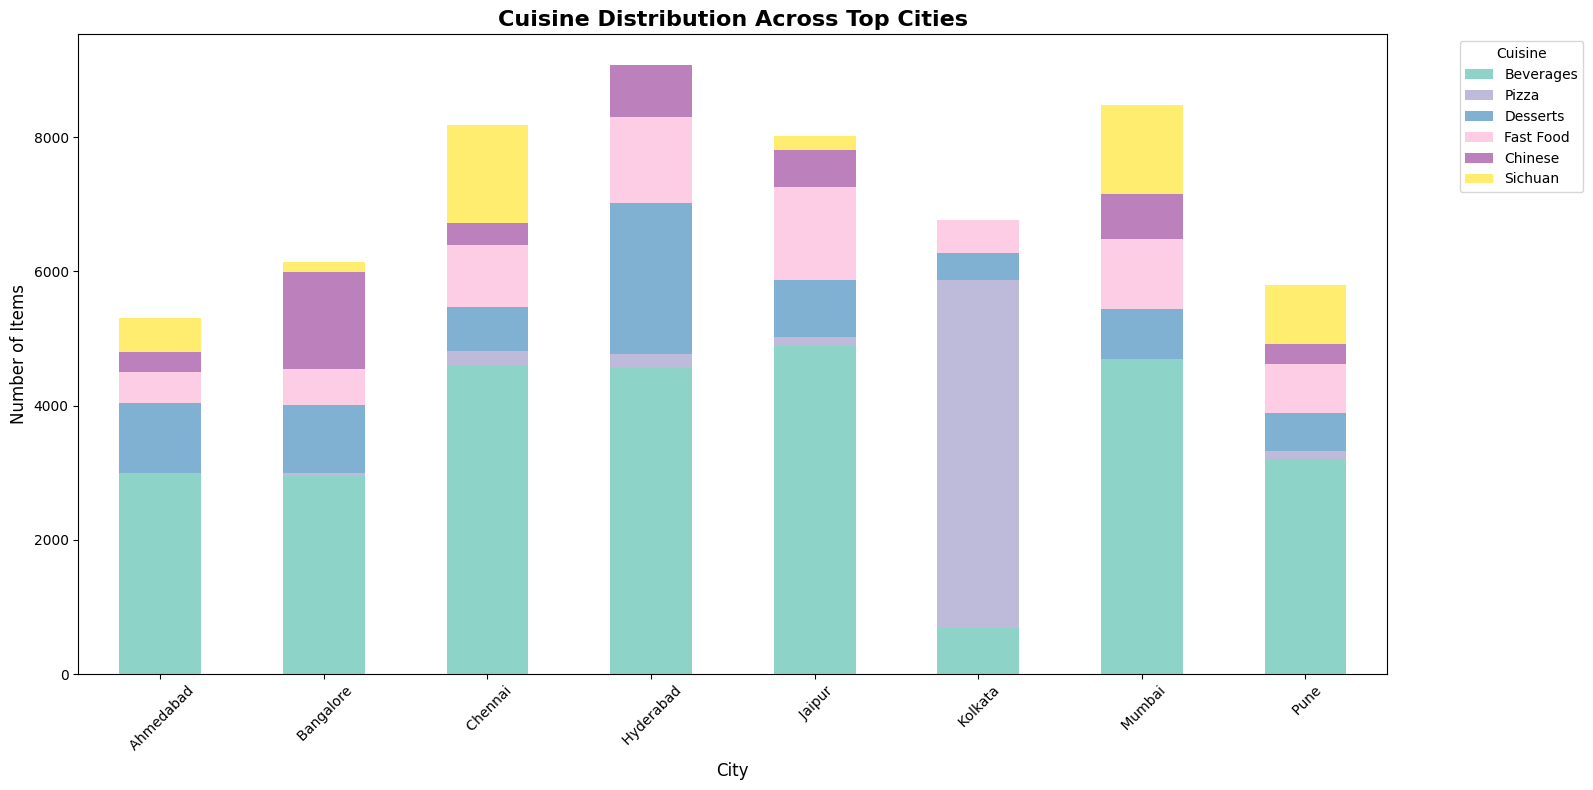

In [59]:
plt.figure(figsize=(16, 8))
top_cities = df['City'].value_counts().head(8).index
top_cuisines = df['Cuisine'].value_counts().head(6).index
cross_tab = pd.crosstab(df[df['City'].isin(top_cities)]['City'], 
                        df[df['City'].isin(top_cities)]['Cuisine'])
cross_tab = cross_tab[top_cuisines]
cross_tab.plot(kind='bar', stacked=True, figsize=(16, 8), colormap='Set3')
plt.title('Cuisine Distribution Across Top Cities', fontsize=16, fontweight='bold')
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Items', fontsize=12)
plt.legend(title='Cuisine', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Hyderabad dominates with beverage offerings, while other cities show more balanced cuisine distributions across different food categories.

#### Price Distribution by Cuisine Type

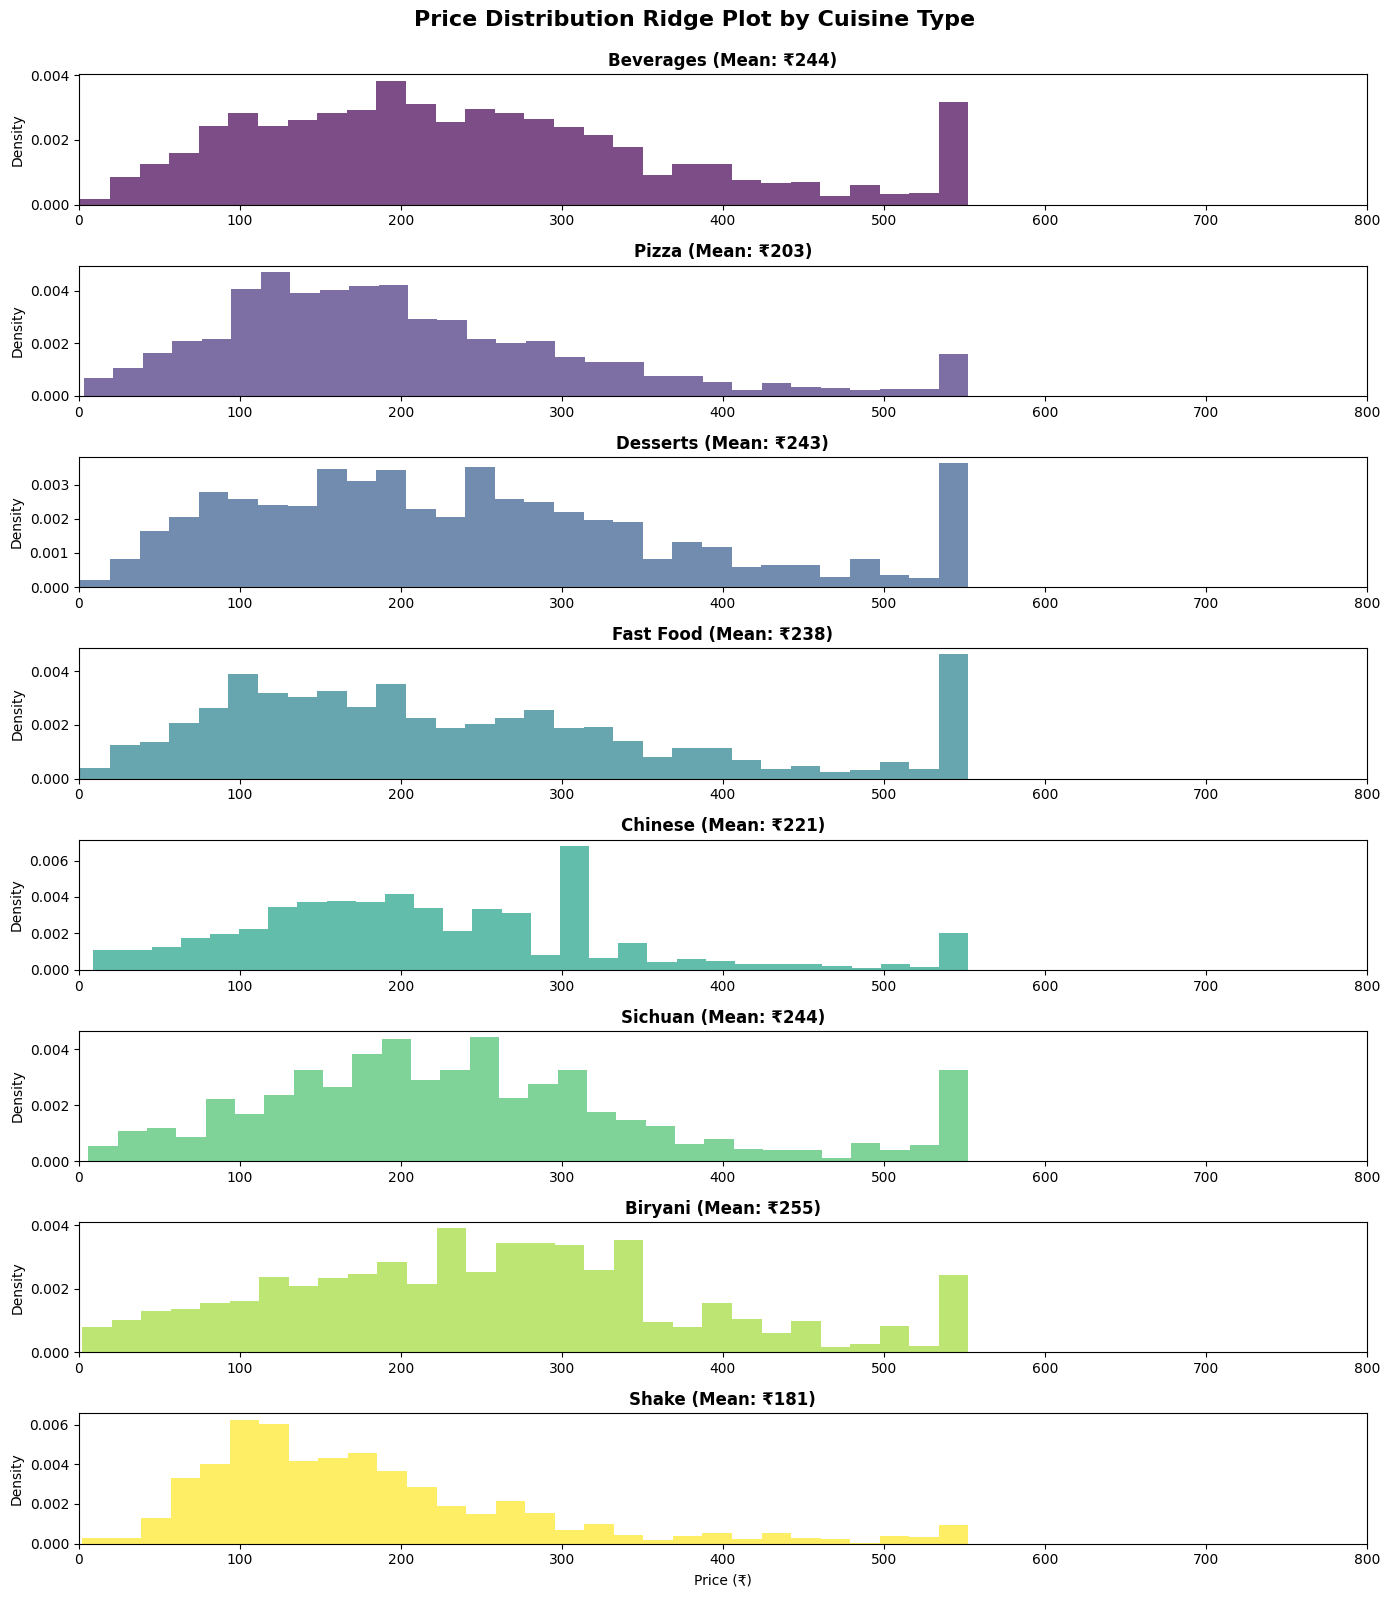

In [60]:
fig, axes = plt.subplots(8, 1, figsize=(14, 16))
top_cuisines = df['Cuisine'].value_counts().head(8).index
colors = plt.cm.viridis(np.linspace(0, 1, 8))

for i, cuisine in enumerate(top_cuisines):
    data = df[df['Cuisine'] == cuisine]['Prices']
    axes[i].hist(data, bins=30, alpha=0.7, color=colors[i], density=True)
    axes[i].set_title(f'{cuisine} (Mean: ₹{data.mean():.0f})', fontsize=12, fontweight='bold')
    axes[i].set_xlim(0, 800)
    axes[i].set_ylabel('Density')
    
axes[-1].set_xlabel('Price (₹)')
plt.suptitle('Price Distribution Ridge Plot by Cuisine Type', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

**Insight**: Continental and North Indian cuisines show wider price ranges, while Beverages and Fast Food maintain concentrated distributions.

### Restaurant Performance Analysis

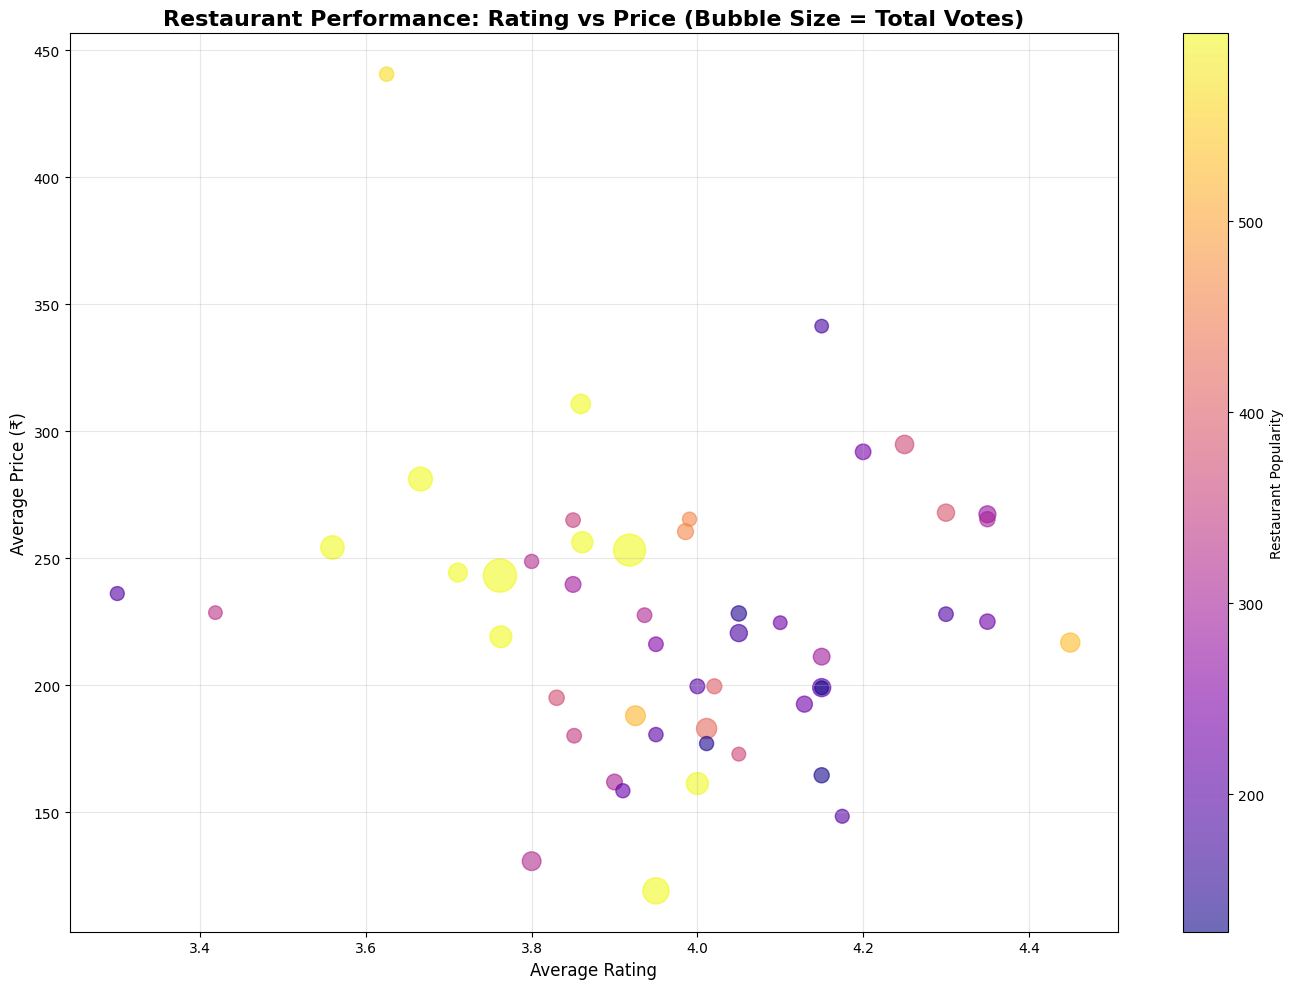

In [61]:
plt.figure(figsize=(14, 10))
restaurant_stats = df.groupby('Restaurant_Name').agg({
    'Average_Rating': 'mean',
    'Prices': 'mean',
    'Votes': 'sum',
    'Restaurant_Popularity': 'first'
}).reset_index()

top_restaurants = restaurant_stats.nlargest(50, 'Votes')
scatter = plt.scatter(top_restaurants['Average_Rating'], top_restaurants['Prices'], 
                     s=top_restaurants['Votes']/20, alpha=0.6, 
                     c=top_restaurants['Restaurant_Popularity'], cmap='plasma')
plt.colorbar(scatter, label='Restaurant Popularity')
plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Average Price (₹)', fontsize=12)
plt.title('Restaurant Performance: Rating vs Price (Bubble Size = Total Votes)', 
          fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: High-rated restaurants command premium prices with larger customer bases, showing clear market segmentation between value and premium segments.

#### Rating Distribution by City

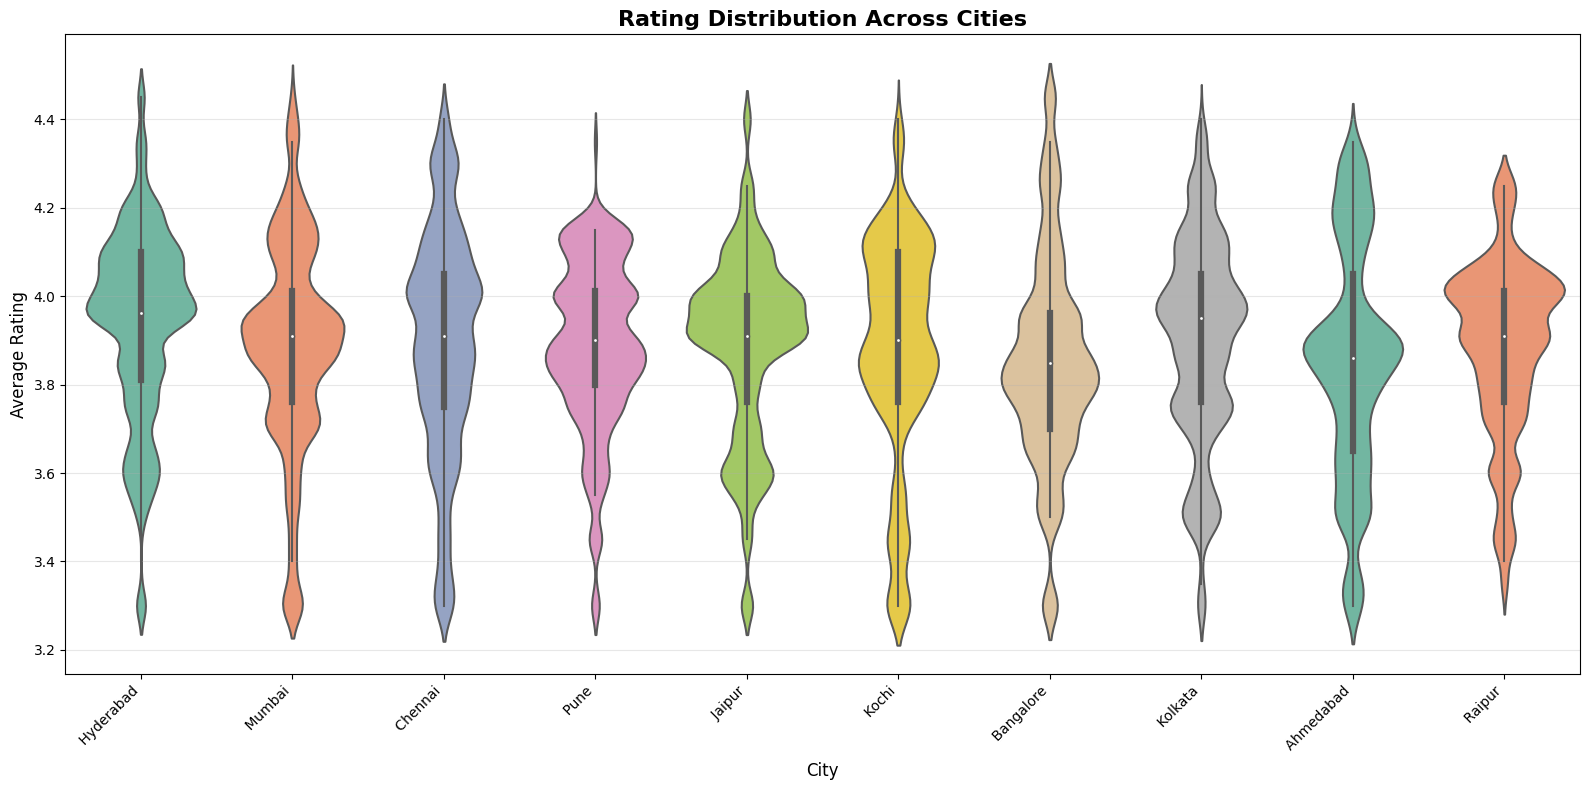

In [62]:
plt.figure(figsize=(16, 8))
top_cities = df['City'].value_counts().head(10).index
city_data = df[df['City'].isin(top_cities)]
sns.violinplot(data=city_data, x='City', y='Average_Rating', palette='Set2')
plt.title('Rating Distribution Across Cities', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.xlabel('City', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Kolkata shows highest rating consistency while Mumbai displays wider rating variance, indicating different market maturity levels.

#### Highly Rated vs Expensive Items by Cuisine

<Figure size 1600x800 with 0 Axes>

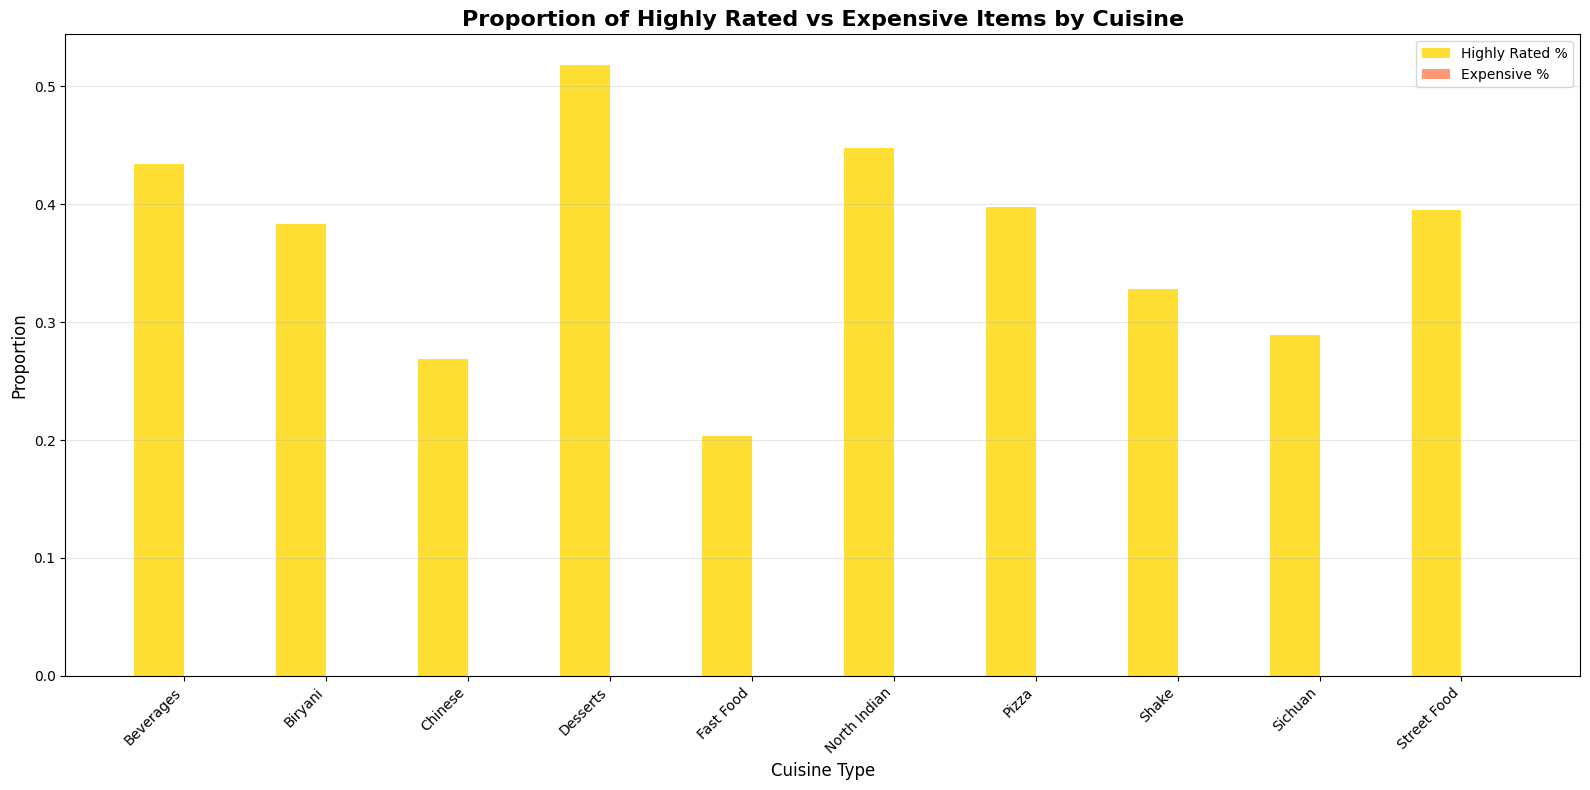

In [63]:
plt.figure(figsize=(16, 8))
top_cuisines = df['Cuisine'].value_counts().head(10).index
cuisine_analysis = df[df['Cuisine'].isin(top_cuisines)].groupby('Cuisine').agg({
    'Is_Highly_Rated': 'mean',
    'Is_Expensive': 'mean'
}).reset_index()

x = np.arange(len(cuisine_analysis))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 8))
bars1 = ax.bar(x - width/2, cuisine_analysis['Is_Highly_Rated'], width, 
               label='Highly Rated %', color='gold', alpha=0.8)
bars2 = ax.bar(x + width/2, cuisine_analysis['Is_Expensive'], width, 
               label='Expensive %', color='coral', alpha=0.8)

ax.set_xlabel('Cuisine Type', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('Proportion of Highly Rated vs Expensive Items by Cuisine', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(cuisine_analysis['Cuisine'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Continental cuisine shows highest proportion of expensive items, while Beverages maintain high ratings with moderate pricing.

#### Multi-dimensional Restaurant Analysis

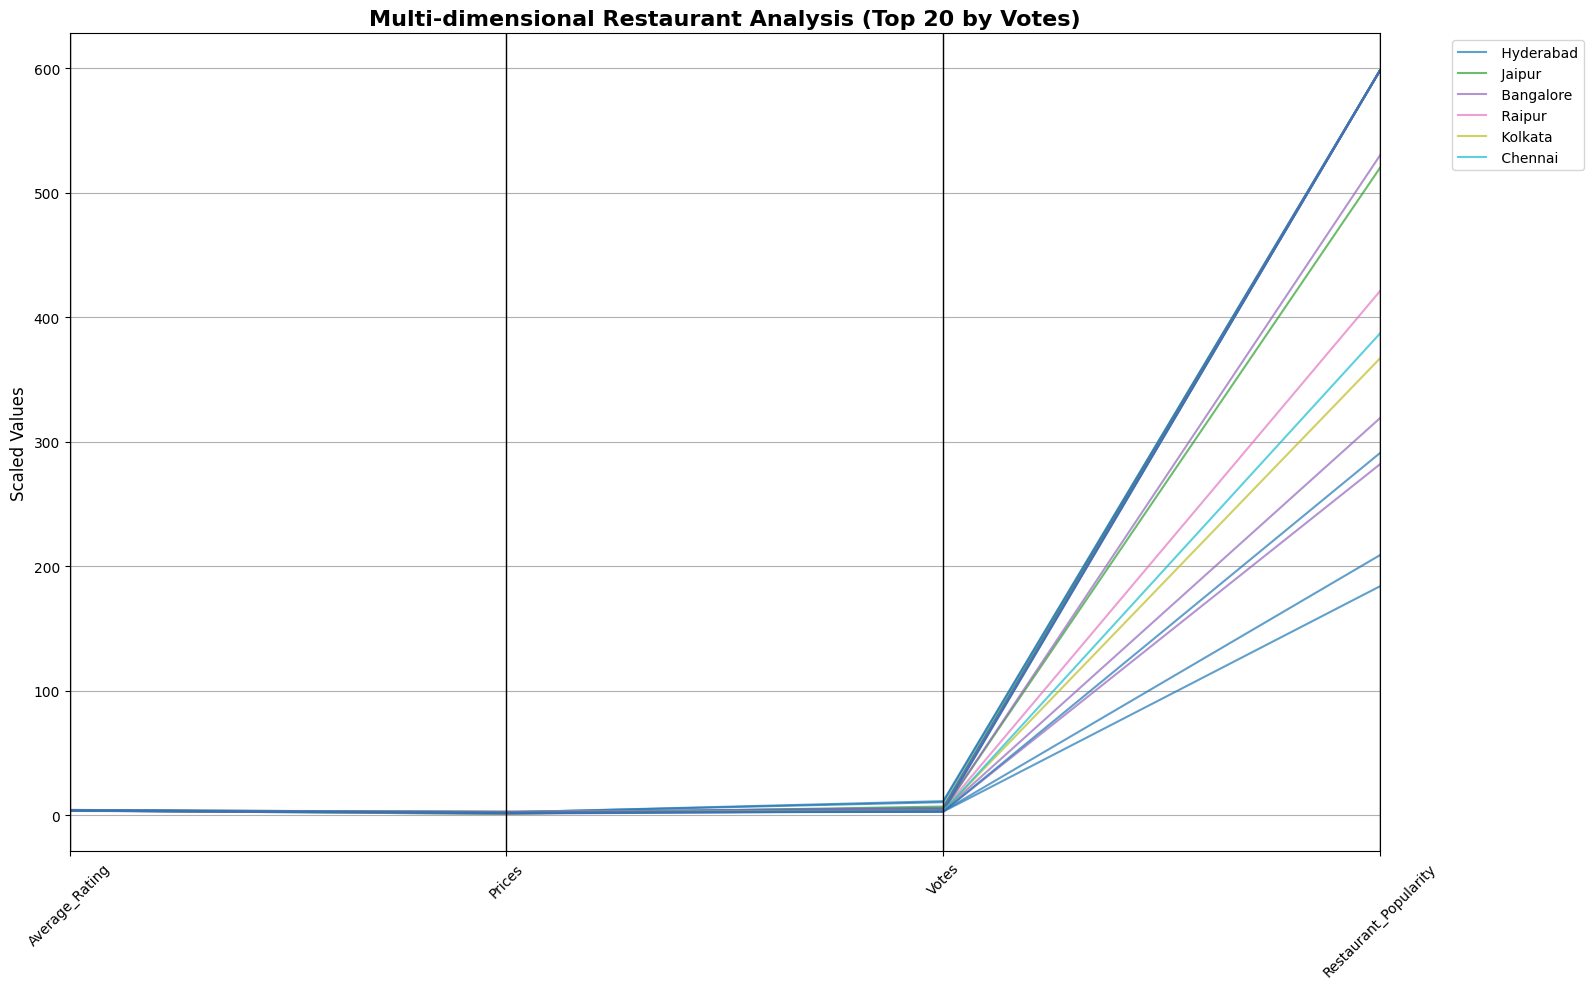

In [65]:
plt.figure(figsize=(16, 10))
restaurant_summary = df.groupby('Restaurant_Name').agg({
    'Average_Rating': 'mean',
    'Prices': 'mean',
    'Votes': 'sum',
    'Restaurant_Popularity': 'first',
    'City': 'first'
}).reset_index()

top_restaurants = restaurant_summary.nlargest(20, 'Votes')
parallel_data = top_restaurants[['Average_Rating', 'Prices', 'Votes', 'Restaurant_Popularity', 'City']]
parallel_data['Prices'] = parallel_data['Prices'] / 100  # Scale for better visualization
parallel_data['Votes'] = parallel_data['Votes'] / 1000   # Scale for better visualization

parallel_coordinates(parallel_data, 'City', colormap='tab10', alpha=0.7)
plt.title('Multi-dimensional Restaurant Analysis (Top 20 by Votes)', fontsize=16, fontweight='bold')
plt.ylabel('Scaled Values', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Insight**: Hyderabad restaurants dominate multiple performance dimensions, while other cities show distinct patterns in rating-price-popularity relationships.

#### Restaurant Distribution by City and Cuisine

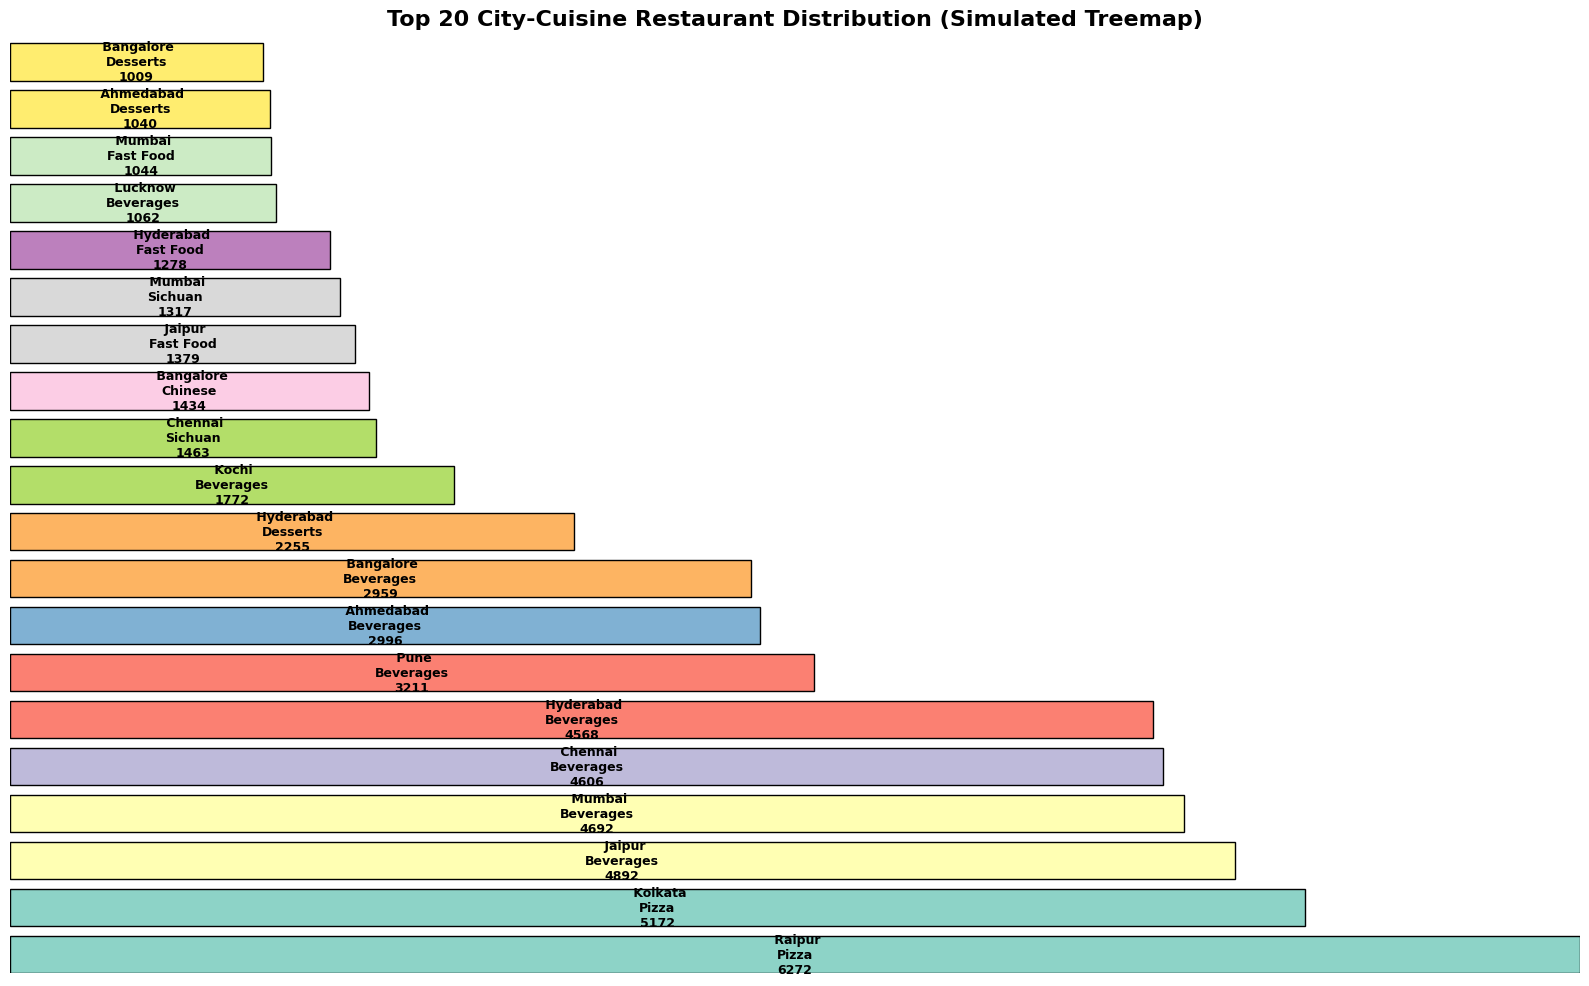

In [68]:
# Group and get top 20 combinations
city_cuisine_counts = df.groupby(['City', 'Cuisine']).size().reset_index(name='count')
top_combinations = city_cuisine_counts.nlargest(20, 'count')

# Plot setup
fig, ax = plt.subplots(figsize=(16, 10))
ax.set_title('Top 20 City-Cuisine Restaurant Distribution (Simulated Treemap)', fontsize=16, fontweight='bold')

# Colors
colors = cm.Set3(np.linspace(0, 1, len(top_combinations)))

# Layout settings
y_pos = 0
max_width = top_combinations['count'].max()

# Loop using range instead of iterrows()
for idx in range(len(top_combinations)):
    row = top_combinations.iloc[idx]  # Access by position
    width = row['count'] / max_width * 100  # Normalize width
    height = 4
    
    rect = patches.Rectangle((0, y_pos), width, height, 
                             facecolor=colors[idx], edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    
    ax.text(width / 2, y_pos + height / 2, 
            f"{row['City']}\n{row['Cuisine']}\n{row['count']}", 
            ha='center', va='center', fontsize=9, fontweight='bold', color='black')
    
    y_pos += height + 1

ax.set_xlim(0, 100)
ax.set_ylim(0, y_pos)
ax.axis('off')
plt.tight_layout()
plt.show()

**Insight**: Hyderabad-Beverages combination dominates the market, followed by Fast Food across multiple cities, indicating beverage-focused business models.

#### Restaurant Performance Metrics

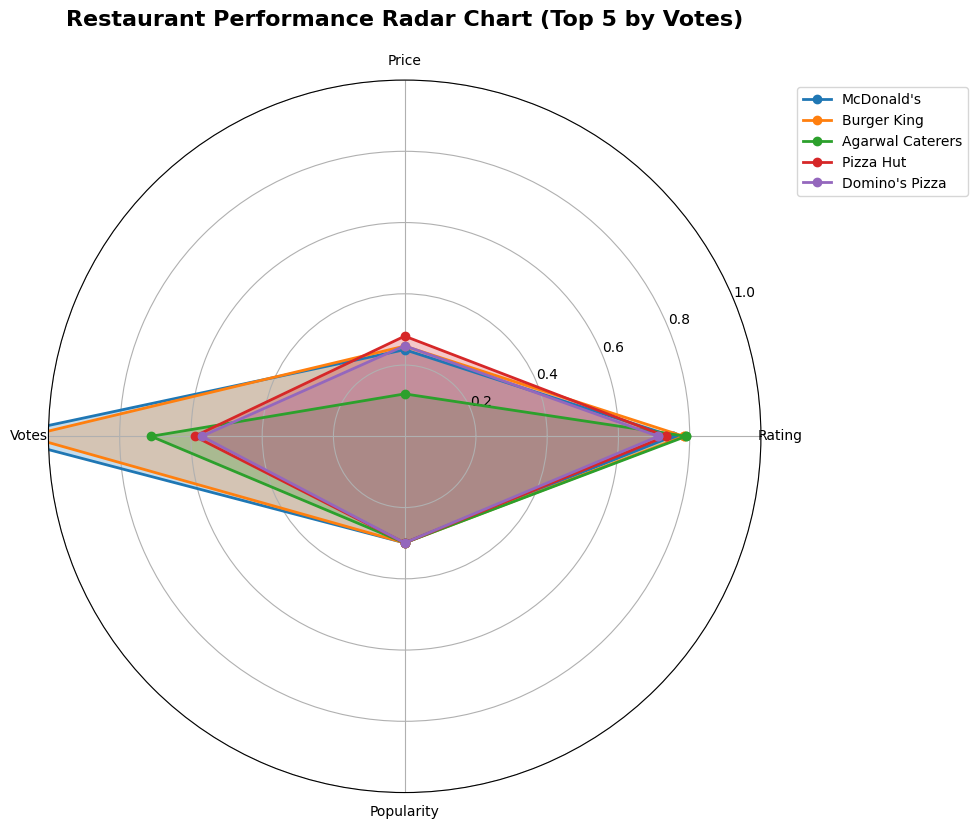

In [70]:
restaurant_metrics = df.groupby('Restaurant_Name').agg({
    'Average_Rating': 'mean',
    'Prices': 'mean',
    'Votes': 'sum',
    'Restaurant_Popularity': 'first'
}).reset_index()

top_5_restaurants = restaurant_metrics.nlargest(5, 'Votes')
categories = ['Rating', 'Price', 'Votes', 'Popularity']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

for i, (_, restaurant) in enumerate(top_5_restaurants.iterrows()):
    values = [
        restaurant['Average_Rating'] / 5,
        restaurant['Prices'] / 1000,
        restaurant['Votes'] / 10000,
        restaurant['Restaurant_Popularity'] / 2000
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=restaurant['Restaurant_Name'])
    ax.fill(angles, values, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
plt.title('Restaurant Performance Radar Chart (Top 5 by Votes)', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
plt.show()

**Insight**: McDonald's shows balanced performance across all metrics, while other restaurants display specialized strengths in specific performance areas.

#### Price Breakdown by Restaurant Categories

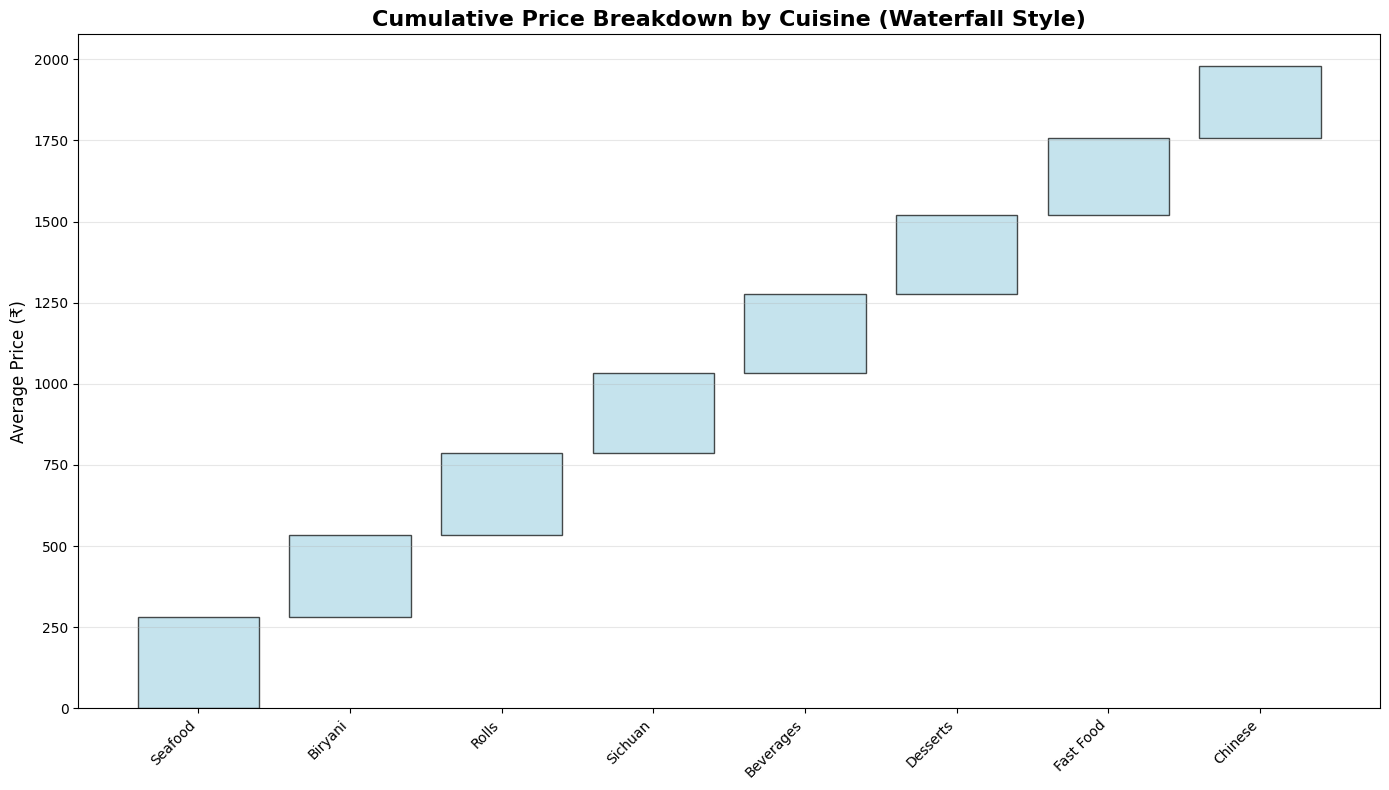

In [73]:
plt.figure(figsize=(14, 8))
price_stats = df.groupby('Cuisine')['Prices'].agg(['mean', 'count']).reset_index()
price_stats = price_stats[price_stats['count'] > 1000].sort_values('mean', ascending=False).head(8)

cumulative = 0
positions = []
heights = []
colors = []

for i, row in price_stats.iterrows():
    positions.append(cumulative)
    heights.append(row['mean'])
    colors.append('lightblue' if row['mean'] > 0 else 'lightcoral')
    cumulative += row['mean']

bars = plt.bar(range(len(positions)), heights, bottom=positions, 
               color=colors, alpha=0.7, edgecolor='black')
plt.xticks(range(len(price_stats)), price_stats['Cuisine'], rotation=45, ha='right')
plt.ylabel('Average Price (₹)', fontsize=12)
plt.title('Cumulative Price Breakdown by Cuisine (Waterfall Style)', fontsize=16, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight**: Continental and North Indian cuisines contribute most to overall price escalation, while Beverages maintain baseline affordability.

## Conclusion

### Key Findings Summary

The comprehensive exploratory data analysis of the Zomato restaurant dataset (123,657 records across 17 Indian cities) reveals several critical insights about the restaurant industry landscape:

#### Market Dynamics
- **Geographic Concentration**: Hyderabad emerges as the dominant market with 15,613 records, primarily driven by beverage offerings
- **Cuisine Diversity**: 48 cuisine types with Beverages leading (39,441 items), followed by Fast Food and North Indian
- **Price Segmentation**: Clear market stratification with prices ranging from ₹0.95 to ₹12,024, showing highly skewed distribution

#### Performance Correlations
- **Strong Rating Consistency**: Dining and delivery ratings show high positive correlation, indicating consistent service quality
- **Price-Quality Relationship**: Premium pricing correlates with higher ratings and popularity scores
- **Vote-Performance Link**: Higher customer engagement (votes) strongly correlates with restaurant popularity and ratings

#### Business Intelligence Insights
- **Menu Optimization Opportunity**: 95K+ items marked as "NONE" in bestseller category suggest untapped promotional potential
- **Regional Pricing Strategies**: Jaipur and Chandigarh lead in expensive item concentration, while Hyderabad maintains moderate pricing
- **Cuisine Positioning**: Continental and North Indian cuisines command premium pricing, while Beverages maintain affordability

#### Data Quality & Structure
- **Comprehensive Coverage**: Well-structured dataset with minimal missing values and robust categorical classifications
- **Multi-dimensional Analysis**: Pre-calculated metrics (Restaurant_Popularity, Price_per_Vote, Is_Highly_Rated) enable sophisticated business analysis
- **Geographic Representation**: Balanced city coverage allows for meaningful regional comparisons

### Strategic Recommendations

#### For Restaurant Operators
1. **Focus on Rating Consistency**: Maintain uniform quality across dining and delivery channels
2. **Strategic Menu Engineering**: Leverage bestseller categorization for revenue optimization
3. **Regional Pricing Adaptation**: Align pricing strategies with local market conditions

#### For Market Analysis
1. **Expansion Opportunities**: Underrepresented cities show potential for market entry
2. **Cuisine Diversification**: Beverage-heavy markets may benefit from food category expansion
3. **Price Positioning**: Clear correlation between pricing and customer satisfaction metrics

### Technical Implementation Success

The analysis successfully utilized multiple visualization techniques including:
- Correlation heatmaps revealing inter-variable relationships
- Multi-dimensional bubble charts showing performance clusters
- Geographic distribution analysis across cities and cuisines
- Time-series and trend analysis through various plotting methods

This EDA provides a solid foundation for advanced analytics, predictive modeling, and strategic decision-making in the restaurant industry domain.
